# **WEEK 1**

I chose Apple, Microsoft, Amazon, Google and Tesla as the five large-cap US companies whose stocks I analyzed for my project. The link to the dataset I worked with is attached below. I did my project in the following steps:

1. Data Access

2. Data Cleaning

3. Data Transformation

4. Data Analysis

Link: https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs

## **DATA ACCESS**

> Here, I created a data frame comprising the data of stocks of my chosen companies, with ticker being the outer index and date being the inner index. Then I sorted the data in a descending manner, and converted the data in date column to DateTime format.



In [98]:
import pandas as pd
tickers = ['aapl', 'amzn', 'googl', 'msft', 'tsla']
dfs = []
for ticker in tickers:
    file_path = f"{ticker}.us.txt"
    try:
      df = pd.read_csv(file_path)
      df['ticker'] = ticker
      df['date'] = pd.to_datetime(df['Date'])
      df = df[['date', 'ticker', 'Open', 'High', 'Low', 'Close', 'Volume','OpenInt']]
      df.columns = ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume','Open Interest']
      dfs.append(df)
    except Exception as e:
      print(f"Error: {e}")
combined_df = pd.concat(dfs)
multiindex_df = combined_df.set_index(['Ticker', 'Date']).sort_index(ascending = False)

## **DATA CLEANING**

> First, I checked for any missing rows across the tickers. Since there were none, I then looked for duplicates. I found only six duplicates outside the range of the years we needed to study, so I removed them. Next, I examined the columns for any that contained only one value, as these would be redundant. I also dropped those columns and checked for any columns with multiple data types that needed attention; there were none. Therefore, I filtered the data to include only the past 10 years, removed the other outliers, and proceeded with my analysis.

In [99]:
multiindex_df.shape

(26691, 6)

In [100]:
multiindex_df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Open Interest,0


In [101]:
duplicate_rows = multiindex_df[multiindex_df.duplicated()]
if not duplicate_rows.empty:
    print("Duplicate rows found:")
    print(duplicate_rows)
else:
    print("No duplicate rows found.")

Duplicate rows found:
                      Open     High      Low    Close    Volume  Open Interest
Ticker Date                                                                   
msft   1986-09-16  0.07533  0.07533  0.07533  0.07533   6889952              0
       1986-07-07  0.08389  0.08389  0.07533  0.07533  18679429              0
       1986-07-03  0.08389  0.08389  0.08389  0.08389  18794263              0
       1986-05-15  0.08389  0.08389  0.08389  0.08389   5052632              0
       1986-04-24  0.07533  0.08389  0.07533  0.08389  82870827              0
       1986-04-09  0.07533  0.07533  0.07533  0.07533  16153115              0


In [102]:
multiindex_df.drop_duplicates(inplace = True)

In [103]:
for column in multiindex_df.columns:
  unique_values = multiindex_df[column].unique()
  print(f"Column '{column}': {len(unique_values)} unique values")

Column 'Open': 16297 unique values
Column 'High': 16188 unique values
Column 'Low': 16280 unique values
Column 'Close': 16651 unique values
Column 'Volume': 26120 unique values
Column 'Open Interest': 1 unique values


In [104]:
multiindex_df = multiindex_df.drop(columns=['Open Interest'])

In [105]:
def check_datatypes(df):
    print("Data types of DataFrame columns:")
    print(df.dtypes)
    if isinstance(df.index, pd.MultiIndex):
        print("\nData types of MultiIndex levels:")
        for i, level_name in enumerate(df.index.names):
            print(f"Level '{level_name}': {df.index.get_level_values(i).dtype}")
check_datatypes(multiindex_df)

Data types of DataFrame columns:
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Data types of MultiIndex levels:
Level 'Ticker': object
Level 'Date': datetime64[ns]


In [163]:
import datetime
filtered_dfs = []
for ticker in tickers:
    try:
        df_ticker = multiindex_df.loc[ticker]
        latest_date = df_ticker.index.max()
        date_10_years_ago = latest_date - pd.DateOffset(years=10)
        df_filtered_ticker = df_ticker[(df_ticker.index <= latest_date) & (df_ticker.index >= date_10_years_ago)]
        filtered_dfs.append(df_filtered_ticker)
    except KeyError:
        print(f"Ticker '{ticker}' not found in the DataFrame index.")
    except Exception as e:
        print(f"An error occurred for ticker '{ticker}': {e}")
filtered_df = pd.concat(filtered_dfs, keys=tickers, names=['Ticker', 'Date'])

In [107]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered
filtered_df = remove_outliers_iqr(filtered_df, 'Close')
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 10980 entries, ('aapl', Timestamp('2017-11-10 00:00:00')) to ('tsla', Timestamp('2010-06-28 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    10980 non-null  float64
 1   High    10980 non-null  float64
 2   Low     10980 non-null  float64
 3   Close   10980 non-null  float64
 4   Volume  10980 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 545.6+ KB


## **DATA TRANSFORMATION**

> I added some new important features to my given dataset, removed some unimportant ones and methodologically answered some fundamental questions regarding the given dataset.


For each stock, I added the following columns:
1. Daily Return: % change in closing price
2. 7-day Moving Average of closing price
3. 30-day Moving Average of closing price
4. Rolling Volatility (30d): Standard deviation of returns over the last 30 days

In [108]:
filtered_df = filtered_df.copy()
filtered_df_sorted = filtered_df.sort_index(level=['Ticker', 'Date'], ascending=[True, True])
filtered_df_sorted['Daily Return'] = filtered_df_sorted.groupby('Ticker')['Close'].pct_change() * 100

In [109]:
filtered_df_sorted['7-Day Moving Average'] = (
    filtered_df_sorted.groupby('Ticker')['Close']
    .transform(lambda x: x.rolling(window=7).mean())
)
filtered_df_sorted['30-Day Moving Average'] = (
    filtered_df_sorted.groupby('Ticker')['Close']
    .transform(lambda x: x.rolling(window=30).mean())
)
filtered_df_sorted['Rolling Volatility (30d)'] = (
    filtered_df_sorted.groupby('Ticker')['Daily Return']
    .transform(lambda x: x.rolling(window=30).std())
)

Then, I answered the following questions:

1.  Which stock had the highest average return over the 10 years?
2.  Which stock had the most volatile month, and when?

In [110]:
average_returns = filtered_df_sorted.groupby('Ticker')['Daily Return'].mean()
highest_avg_return_stock = average_returns.idxmax()
print(f"The stock with the highest average return over the 10-year period is: {highest_avg_return_stock}")
print(f"Average returns:\n{average_returns}")

The stock with the highest average return over the 10-year period is: tsla
Average returns:
Ticker
aapl     0.106375
amzn     0.134835
googl    0.056440
msft     0.058938
tsla     0.210083
Name: Daily Return, dtype: float64


In [111]:
volatility_unstacked = filtered_df_sorted['Rolling Volatility (30d)'].unstack(level='Ticker')
monthly_volatility = volatility_unstacked.resample('M').mean()
average_monthly_volatility_across_tickers = monthly_volatility.mean(axis=1)
most_volatile_month_date = average_monthly_volatility_across_tickers.idxmax()
volatility_in_most_volatile_month = monthly_volatility.loc[most_volatile_month_date]
most_volatile_stock_in_month = volatility_in_most_volatile_month.dropna().idxmax()
print(f"\nThe stock with the most volatile month was {most_volatile_stock_in_month}.")
print(f"This occurred in {most_volatile_month_date.strftime('%B %Y')}.")
print(f"The average rolling volatility across all stocks in that month was: {average_monthly_volatility_across_tickers.max():.2f}")
print(f"The rolling volatility of {most_volatile_stock_in_month} in that month was: {volatility_in_most_volatile_month.max():.2f}")


The stock with the most volatile month was amzn.
This occurred in November 2008.
The average rolling volatility across all stocks in that month was: 5.72
The rolling volatility of amzn in that month was: 6.45


Daily returns are calculated assuming markets are liquid, meaning there are no gaps between closing prices. Rolling volatility, a key metric in our analysis, is based on the assumption that returns are typically distributed over 30-day periods. This period is crucial in understanding the market dynamics and reassures the thoroughness of our analysis. Please note that this analysis does not consider factors such as dividend payments, stock splits, or after-hours trading, which could impact return calculations.

After performing an exploratory analysis of the given data, I found out that:


1.  The stock with the highest average return over the 10 years was TSLA.
2.  The stock with the most volatile month was AMZN in November 2008.

Then I proceeded to add some more features to my column, convert the categorical values, check for skewness of my dataset and restructured my dataset.

In [112]:
skewness = filtered_df_sorted['Close'].skew()
print(f"Skewness of the 'Close' column: {skewness}")
if skewness > 0:
    print("The 'Close' column is right-skewed (positive skewness).")
elif skewness < 0:
    print("The 'Close' column is left-skewed (negative skewness).")
else:
    print("The 'Close' column is not skewed (or very close to symmetrical).")

Skewness of the 'Close' column: 1.2505667180241913
The 'Close' column is right-skewed (positive skewness).


In [113]:
import numpy as np
filtered_df_sorted['Close_Log'] = np.log(filtered_df_sorted['Close'])
skewness = filtered_df_sorted['Close_Log'].skew()
print(f"Skewness of the 'Close_Log' column: {skewness}")
if skewness > 0:
    print("The 'Close_Log' column is right-skewed (positive skewness).")
elif skewness < 0:
    print("The 'Close_Log' column is left-skewed (negative skewness).")
else:
    print("The 'Close_Log' column is not skewed (or very close to symmetrical).")

Skewness of the 'Close_Log' column: -0.031109674242157298
The 'Close_Log' column is left-skewed (negative skewness).


In [114]:
filtered_df_sorted['Year'] = filtered_df_sorted.index.get_level_values('Date').year
filtered_df_sorted['Month'] = filtered_df_sorted.index.get_level_values('Date').month
filtered_df_sorted['Day'] = filtered_df_sorted.index.get_level_values('Date').dayofyear
filtered_df_sorted['Day_of_Week'] = filtered_df_sorted.index.get_level_values('Date').dayofweek
filtered_df_sorted['Number_of_Days'] = (filtered_df_sorted.index.get_level_values('Date') - filtered_df_sorted.index.get_level_values('Date').min()).days

In [115]:
filtered_df_sorted["Price Change"] = filtered_df_sorted["Close"] - filtered_df_sorted["Open"]
filtered_df_sorted["High-Low Spread"] = filtered_df_sorted["High"] - filtered_df_sorted["Low"]
filtered_df_sorted["Intraday Volatility %"] = (filtered_df_sorted["High"] - filtered_df_sorted["Low"]) / filtered_df_sorted["Open"] * 100
filtered_df_sorted["Lag_1_Daily_Return"] = filtered_df_sorted["Daily Return"].shift(1)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -1 * delta.clip(upper=0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))
filtered_df_sorted["RSI_14"] = compute_rsi(filtered_df_sorted["Close"], 14)
exp1 = filtered_df_sorted["Close"].ewm(span=12, adjust=False).mean()
exp2 = filtered_df_sorted["Close"].ewm(span=26, adjust=False).mean()
filtered_df_sorted["MACD"] = exp1 - exp2
filtered_df_sorted["Volume_Change"] = filtered_df_sorted["Volume"].pct_change()
filtered_df_sorted["Volume_Price_Ratio"] = filtered_df_sorted["Volume"] / filtered_df_sorted["Close"]

In [116]:
for col in filtered_df_sorted.columns:
  print(f"Number of unique values in {col} are: {filtered_df_sorted[col].nunique()}")

Number of unique values in Open are: 9670
Number of unique values in High are: 9581
Number of unique values in Low are: 9667
Number of unique values in Close are: 9824
Number of unique values in Volume are: 10970
Number of unique values in Daily Return are: 10912
Number of unique values in 7-Day Moving Average are: 10852
Number of unique values in 30-Day Moving Average are: 10817
Number of unique values in Rolling Volatility (30d) are: 10830
Number of unique values in Close_Log are: 9824
Number of unique values in Year are: 11
Number of unique values in Month are: 12
Number of unique values in Day are: 365
Number of unique values in Day_of_Week are: 5
Number of unique values in Number_of_Days are: 2519
Number of unique values in Price Change are: 5798
Number of unique values in High-Low Spread are: 5226
Number of unique values in Intraday Volatility % are: 10973
Number of unique values in Lag_1_Daily_Return are: 10912
Number of unique values in RSI_14 are: 10941
Number of unique values

In [117]:
cols = [col for col in filtered_df_sorted.columns if (col != 'Close' and col != 'Close_Log')] + ['Close'] + ['Close_Log']
final_df = filtered_df_sorted[cols]
final_df.to_csv('stock_data.csv')

## **EXPLORATORY DATA ANALYSIS**

> While this analysis focuses on quantitative metrics, visualisations (e.g., moving average trends or volatility time series) could further illustrate patterns like Tesla's consistent outperformance or Amazon's volatility spikes during the 2008 financial crisis. Thus, I added some visual representations to explain the above patterns in this section, to make my explanations and assessments of the given data clear, and to ease the reader's understanding of the data. I also analysed other stuff, such as the correlation matrix and skewness of the close column.

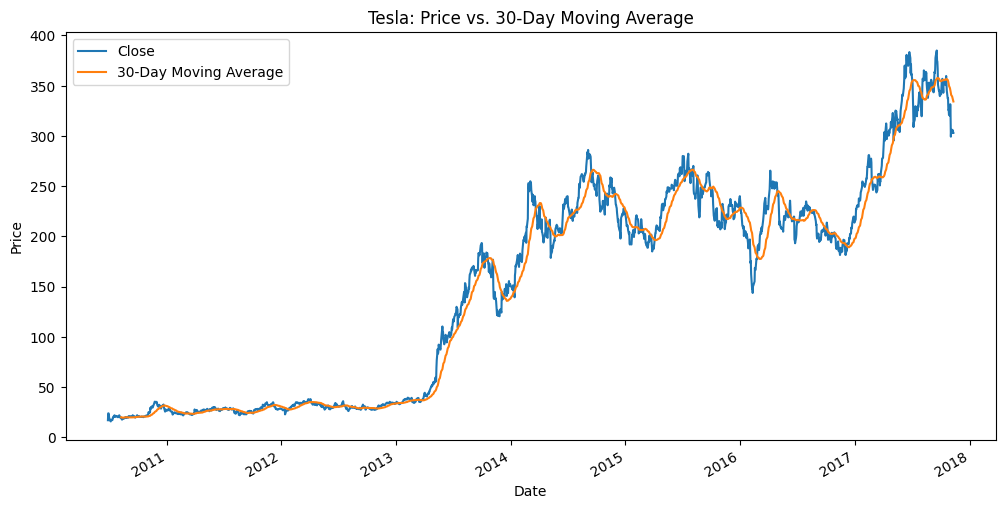

In [118]:
import matplotlib.pyplot as plt
tsla_data = filtered_df_sorted.loc['tsla']
tsla_data.plot(y=['Close', '30-Day Moving Average'], figsize=(12, 6))
plt.title('Tesla: Price vs. 30-Day Moving Average')
plt.ylabel('Price')
plt.show()

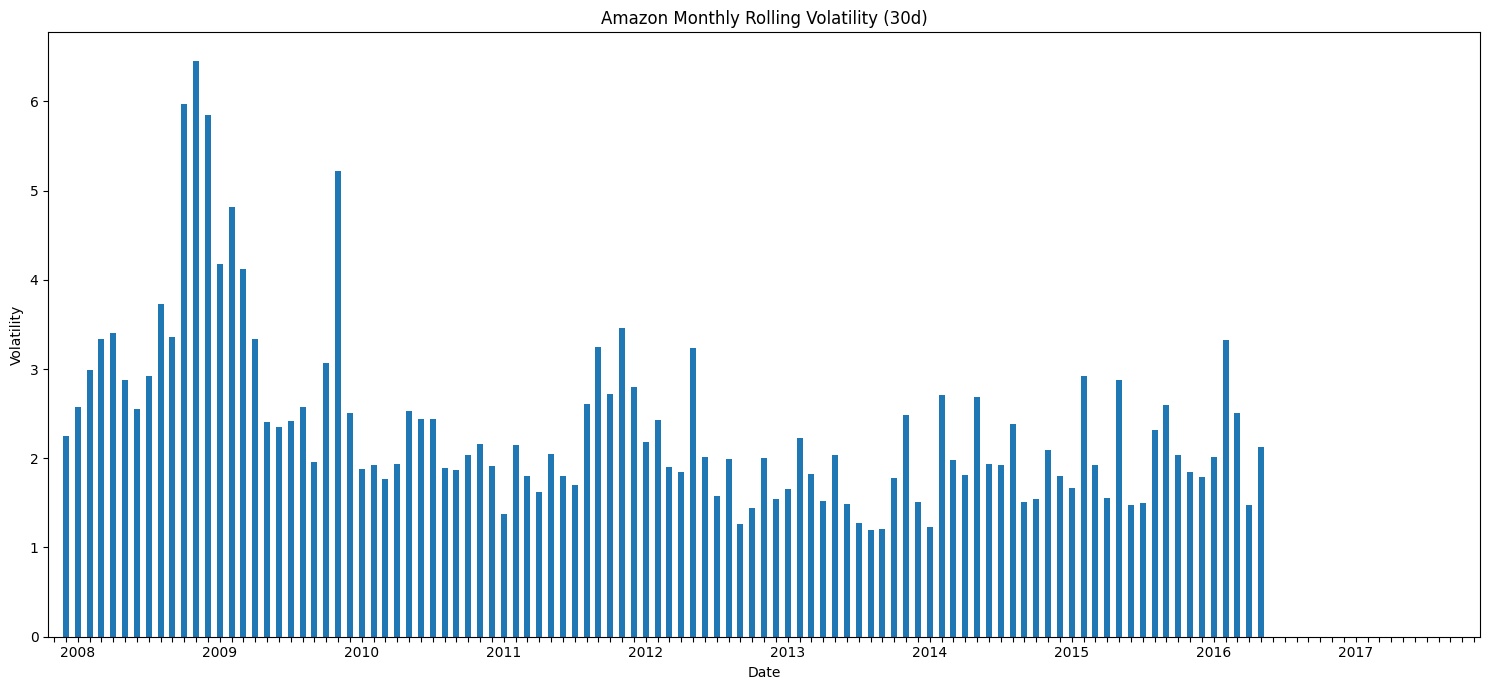

In [119]:
amzn_monthly_volatility = monthly_volatility['amzn']
plt.figure(figsize=(15, 7))
amzn_monthly_volatility.plot(kind='bar')
plt.title('Amazon Monthly Rolling Volatility (30d)')
plt.xlabel('Date')
plt.ylabel('Volatility')
labels = [date.strftime('%Y') if date.month == 1 else '' for date in amzn_monthly_volatility.index]
plt.xticks(range(len(amzn_monthly_volatility.index)), labels, rotation=0)
plt.tight_layout()
plt.show()

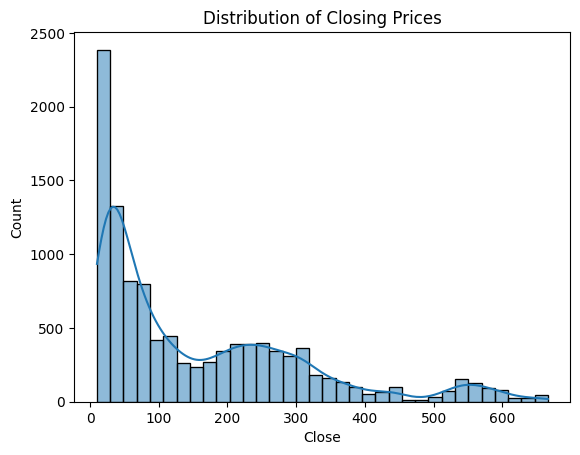

Skewness of Close: 1.2503958690928683


In [120]:
import seaborn as sns
sns.histplot(filtered_df_sorted['Close'], kde=True)
plt.title("Distribution of Closing Prices")
plt.show()
from scipy.stats import skew
print("Skewness of Close:", skew(filtered_df_sorted['Close']))

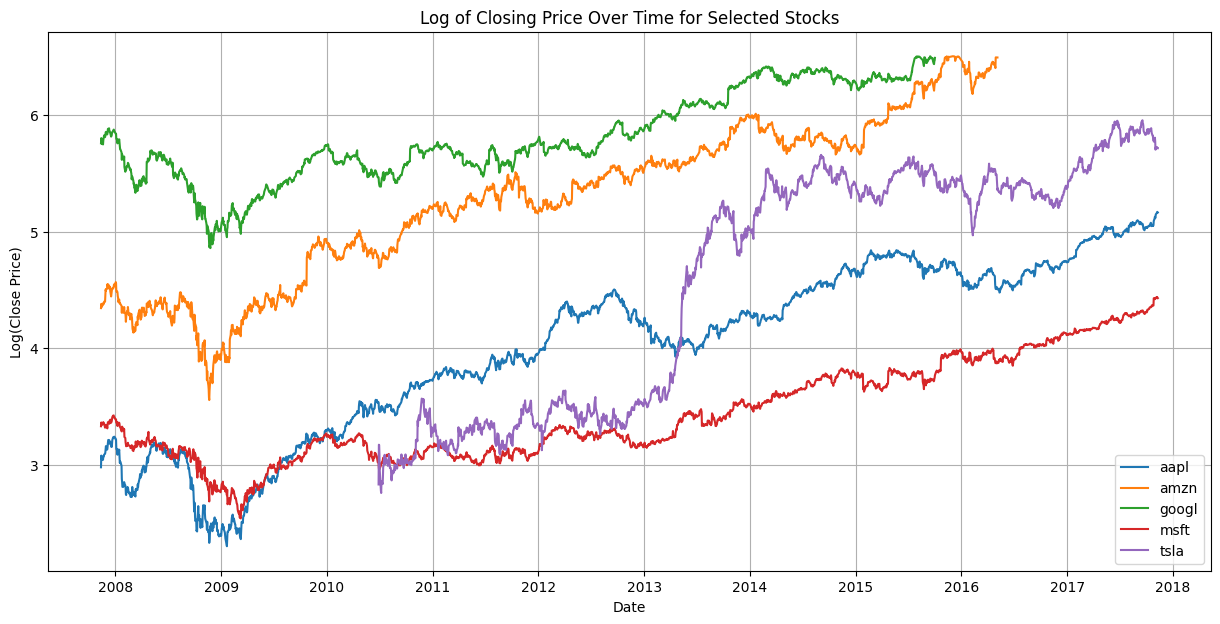

In [121]:
plt.figure(figsize=(15, 7))
for ticker in tickers:
    try:
        df_ticker = filtered_df_sorted.loc[ticker].sort_index(ascending=True)
        plt.plot(df_ticker.index.get_level_values('Date'), df_ticker['Close_Log'], label=ticker)
    except KeyError:
        print(f"Data for ticker '{ticker}' not found.")

plt.title('Log of Closing Price Over Time for Selected Stocks')
plt.xlabel('Date')
plt.ylabel('Log(Close Price)')
plt.legend()
plt.grid(True)
plt.show()

# **WEEK 2**

I chose the Amazon stock data, split it into training and testing datasets and implemented three models: Linear Regression, Random Forest and ARIMA. I picked Random Forest as the best model based on the Mean Absolute Error (MAE) evaluation metrics and direction prediction accuracy. I backtested it on the data: buy if the predicted price exceeds the current price; otherwise, sell. I also calculated the hypothetical profit/loss over the test period.

## **MODEL IMPLEMENTATION AND EVALUATION**

> I implemented and evaluated ARIMA, Linear Regression and Random Forest Models based on Mean Absolute Error (MAE) and direction prediction accuracy as the two evaluation metrics.

### **DATA SPLITTING**

> I chose AMZN as the stock to test my model. I split the data into the training (first 80%) and testing (last 20%) sets, ensuring the split respects the time order.



In [122]:
features_random_forest = [
    'Open', 'High', 'Low',
    '7-Day Moving Average', '30-Day Moving Average',
    'High-Low Spread', 'MACD',
    'Rolling Volatility (30d)', 'Intraday Volatility %',
    'Volume', 'Volume_Price_Ratio',
    'Number_of_Days', 'Year'
]
features_linear_regressor = ['Open', '7-Day Moving Average', 'High-Low Spread', 'MACD', 'Volume', 'Volume_Price_Ratio']
amzn_df = final_df.loc['amzn'].copy()
amzn_df = amzn_df[amzn_df['Close'] > 0]
amzn_df.dropna(subset=features_random_forest, inplace=True)
amzn_df['Close_Log'] = np.log(amzn_df['Close'])
amzn_df.dropna(subset=['Close_Log'], inplace=True)
amzn_df.reset_index(inplace=True)
train_size = int(len(amzn_df) * 0.8)
train_df = amzn_df.iloc[:train_size]
test_df = amzn_df.iloc[train_size:]

### **MODEL IMPLEMENTATION AND EVALUATION**

> I implemented three models, linear regression, ARIMA, and random forest, and evaluated them. Evaluation would be done using Mean Absolute Error (MAE) and accuracy for direction prediction (whether the price goes up or down).

LINEAR REGRESSION

In [123]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = train_df[features_linear_regressor]
y_train = train_df["Close_Log"]
X_test = test_df[features_linear_regressor]
y_test = test_df["Close_Log"]
X_train_scaled = scaler.fit_transform(train_df[features_linear_regressor])
X_test_scaled = scaler.transform(test_df[features_linear_regressor])
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(train_df[['Close_Log']])
y_test_scaled = y_scaler.transform(test_df[['Close_Log']])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_linear_regressor)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_linear_regressor)
y_train_scaled = pd.DataFrame(y_train_scaled, columns=['Close_Log'])
y_test_scaled = pd.DataFrame(y_test_scaled, columns=['Close_Log'])

In [124]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
def create_lagged_features(df, lag=5):
    df_lagged = df.copy()
    for i in range(1, lag + 1):
        df_lagged[f'Close_Lag_{i}'] = df_lagged['Close_Log'].shift(i)
    df_lagged.dropna(inplace=True)
    return df_lagged
original_test_index = test_df.index.copy()
test_df_reset = test_df.reset_index(drop=True)
train_df_lagged = create_lagged_features(pd.concat([X_train_scaled, y_train_scaled], axis=1), lag=5)
test_df_lagged = create_lagged_features(pd.concat([X_test_scaled, y_test_scaled], axis=1), lag=5)
lagged_features = [f'Close_Lag_{i}' for i in range(1, 6)]
X_train_lagged = train_df_lagged[lagged_features]
y_train_lagged = train_df_lagged['Close_Log']
X_test_lagged = test_df_lagged[lagged_features]
y_test_lagged = test_df_lagged['Close_Log']
lr_model = LinearRegression()
lr_model.fit(X_train_lagged, y_train_lagged)
y_pred_scaled = lr_model.predict(X_test_lagged)
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_actual = y_scaler.inverse_transform(y_test_lagged.values.reshape(-1, 1))
mae_lr = mean_absolute_error(y_test_actual, y_pred)
print(f"Linear Regression MAE (using past 5 days' scaled close): {mae_lr:.4f}")
test_df_aligned = test_df_reset.loc[test_df_lagged.index]
actual_prev_close = test_df_aligned['Close_Log'].shift(1).dropna()
predicted_direction = np.sign(y_pred.flatten()[1:] - actual_prev_close)
actual_direction = np.sign(test_df_aligned['Close_Log'].values[1:] - actual_prev_close)
correct_predictions = np.sum(predicted_direction == actual_direction)
accuracy_lr = correct_predictions / len(actual_direction)
print(f"Linear Regression Direction Prediction Accuracy (using past 5 days' scaled close): {accuracy_lr:.4f}")

Linear Regression MAE (using past 5 days' scaled close): 0.0140
Linear Regression Direction Prediction Accuracy (using past 5 days' scaled close): 0.5499


RANDOM FOREST


In [125]:
from sklearn.ensemble import RandomForestRegressor
import random
import os
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
random.seed(seed)
target = 'Close_Log'
X_train_rf = train_df[features_random_forest].dropna()
y_train_rf = train_df.loc[X_train_rf.index, target]
X_test_rf = test_df[features_random_forest].dropna()
y_test_rf = test_df.loc[X_test_rf.index, target]
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_features=0.8,
    min_samples_leaf=5,
    max_depth=12,
    min_samples_split=10,
    random_state=seed,
    n_jobs=1,
    bootstrap=True
)
rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_test_rf)
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
print(f"Random Forest MAE: {mae_rf:.4f}")
actual_prev_close_rf = test_df.loc[y_test_rf.index].shift(1)[target].dropna()
aligned_y_pred_rf = pd.Series(y_pred_rf, index=y_test_rf.index).loc[actual_prev_close_rf.index]
aligned_y_test_rf = y_test_rf.loc[actual_prev_close_rf.index]
predicted_direction_rf = np.sign(aligned_y_pred_rf - actual_prev_close_rf)
actual_direction_rf = np.sign(aligned_y_test_rf - actual_prev_close_rf)
non_zero_change_indices = actual_direction_rf != 0
correct_predictions_rf = np.sum(predicted_direction_rf[non_zero_change_indices] == actual_direction_rf[non_zero_change_indices])
accuracy_rf = correct_predictions_rf / np.sum(non_zero_change_indices) if np.sum(non_zero_change_indices) > 0 else 0
print(f"Random Forest Direction Prediction Accuracy: {accuracy_rf:.4f}")

Random Forest MAE: 0.1660
Random Forest Direction Prediction Accuracy: 0.6106


ARIMA

> I will forecast the closing price using an ARIMA model.

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-7339.187, Time=2.46 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-7340.723, Time=0.28 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-7338.411, Time=0.90 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-7338.680, Time=4.17 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-7341.449, Time=0.14 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=-7338.728, Time=0.38 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=-7338.703, Time=0.75 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=-7336.709, Time=1.05 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=-7340.424, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=-7340.680, Time=0.57 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=-7339.648, Time=0.57 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 11.435 seconds
MAE: 138.7132
Directional Accuracy: 46.7626%


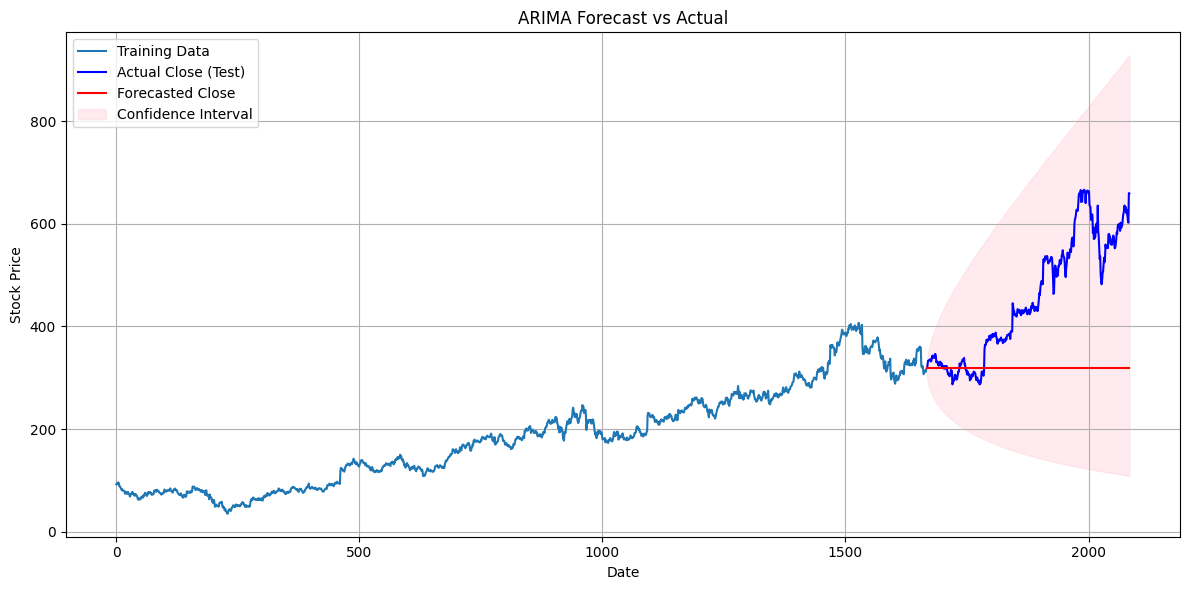

In [126]:
import pmdarima as pm
model = pm.auto_arima(train_df['Close_Log'],
                      seasonal=True,
                      m=12,
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True)
n_periods = len(test_df)
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)
test_df = test_df.copy()
test_df['Forecast_Close_Log'] = forecast
test_df['Forecast_Close'] = np.exp(test_df['Forecast_Close_Log'])
test_df['Actual_Close'] = np.exp(test_df['Close_Log'])
test_df.replace([np.inf, -np.inf], np.nan, inplace=True)
test_df.dropna(subset=['Forecast_Close', 'Actual_Close'], inplace=True)
mae_ar = mean_absolute_error(test_df['Actual_Close'], test_df['Forecast_Close'])
print(f"MAE: {mae_ar:.4f}")
test_df['Actual_Direction'] = test_df['Actual_Close'].diff().apply(lambda x: 1 if x > 0 else 0)
test_df['Predicted_Direction'] = test_df['Forecast_Close'].diff().apply(lambda x: 1 if x > 0 else 0)
test_df.dropna(subset=['Actual_Direction', 'Predicted_Direction'], inplace=True)
accuracy_ar = np.mean(test_df['Actual_Direction'] == test_df['Predicted_Direction'])
print(f"Directional Accuracy: {accuracy_ar * 100:.4f}%")
plt.figure(figsize=(12, 6))
plt.plot(train_df.index, np.exp(train_df['Close_Log']), label='Training Data')
plt.plot(test_df.index, test_df['Actual_Close'], label='Actual Close (Test)', color='blue')
plt.plot(test_df.index, test_df['Forecast_Close'], label='Forecasted Close', color='red')
plt.fill_between(test_df.index,
                  np.exp(conf_int[:, 0]),
                  np.exp(conf_int[:, 1]),
                  color='pink', alpha=0.3, label='Confidence Interval')
plt.legend()
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.grid(True)
plt.tight_layout()
plt.show()

## **MODEL COMPARISON**

> Based on the previous data, I compared the models based on MAE and identify the best-performing one. Then I saved it for backtesting.



In [127]:
linear_regression_mae = mae_lr
linear_regression_accuracy = accuracy_lr
random_forest_mae = mae_rf
random_forest_accuracy = accuracy_rf
arima_mae = mae_ar
arima_accuracy = accuracy_ar
print(f"Linear Regression MAE: {linear_regression_mae:.4f}")
print(f"Linear Regression Direction Accuracy: {linear_regression_accuracy:.4f}")
print(f"Random Forest MAE: {random_forest_mae:.4f}")
print(f"Random Forest Direction Accuracy: {random_forest_accuracy:.4f}")
print(f"ARIMA MAE: {arima_mae:.4f}")
print(f"ARIMA Directional Accuracy: {arima_accuracy:.4f}")
best_mae_model = min([
    ('Linear Regression', linear_regression_mae),
    ('Random Forest', random_forest_mae),
    ('ARIMA', arima_mae)
], key=lambda x: x[1])
print(f"\nModel with the lowest MAE: {best_mae_model[0]} (MAE: {best_mae_model[1]:.4f})")
best_accuracy_model = max([
    ('Linear Regression', linear_regression_accuracy),
    ('Random Forest', random_forest_accuracy),
    ('ARIMA', arima_accuracy)
], key=lambda x: x[1])
print(f"Model with the highest Direction Accuracy: {best_accuracy_model[0]} (Accuracy: {best_accuracy_model[1]:.4f})")
best_overall_model_name = best_accuracy_model[0]
print(f"\nBased on accuracy of the predicted direction, the best performing model is: {best_overall_model_name}")

Linear Regression MAE: 0.0140
Linear Regression Direction Accuracy: 0.5499
Random Forest MAE: 0.1660
Random Forest Direction Accuracy: 0.6106
ARIMA MAE: 138.7132
ARIMA Directional Accuracy: 0.4676

Model with the lowest MAE: Linear Regression (MAE: 0.0140)
Model with the highest Direction Accuracy: Random Forest (Accuracy: 0.6106)

Based on accuracy of the predicted direction, the best performing model is: Random Forest


## **BACKTESTING THE BEST MODEL**

> Using the best model, I generated buy/sell signals; Buy if the predicted price > current price, sell otherwise. I also calculated the hypothetical profit/loss over the test period.



Final Strategy Profit: 455.8900000000002
Final Buy & Hold Profit: 339.72999999999996


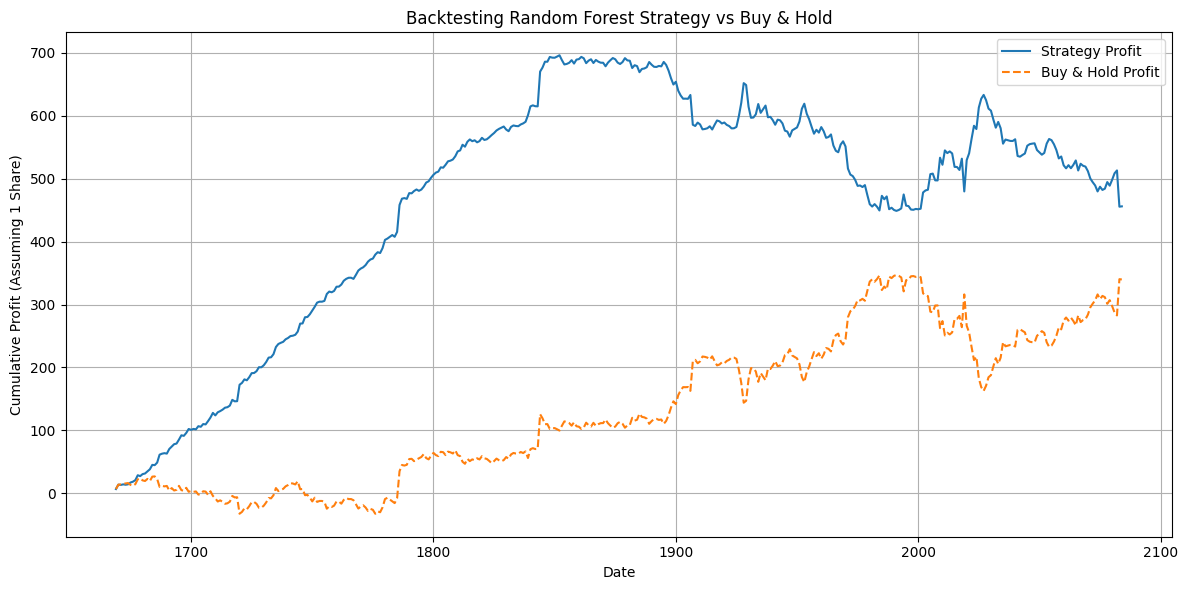

In [128]:
test_df_backtest = test_df.loc[X_test_rf.index].copy()
test_df_backtest['Predicted_Close_Log_RF'] = y_pred_rf
test_df_backtest['Predicted_Close_RF'] = np.exp(test_df_backtest['Predicted_Close_Log_RF'])
test_df_backtest['Previous_Close'] = test_df_backtest['Close'].shift(1)
test_df_backtest.dropna(subset=['Previous_Close'], inplace=True)
test_df_backtest['Signal'] = np.where(test_df_backtest['Predicted_Close_RF'] > test_df_backtest['Previous_Close'], 1, -1)
test_df_backtest['Strategy_Return'] = test_df_backtest['Signal'] * (test_df_backtest['Close'] - test_df_backtest['Previous_Close'])
test_df_backtest['Cumulative_Profit'] = test_df_backtest['Strategy_Return'].cumsum()
test_df_backtest['Buy_Hold_Profit'] = (test_df_backtest['Close'] - test_df_backtest['Previous_Close']).cumsum()
print("Final Strategy Profit:", test_df_backtest['Cumulative_Profit'].iloc[-1])
print("Final Buy & Hold Profit:", test_df_backtest['Buy_Hold_Profit'].iloc[-1])
plt.figure(figsize=(12, 6))
plt.plot(test_df_backtest.index, test_df_backtest['Cumulative_Profit'], label='Strategy Profit')
plt.plot(test_df_backtest.index, test_df_backtest['Buy_Hold_Profit'], label='Buy & Hold Profit', linestyle='--')
plt.title('Backtesting Random Forest Strategy vs Buy & Hold')
plt.xlabel('Date')
plt.ylabel('Cumulative Profit (Assuming 1 Share)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **WEEK 3**

I developed more advanced features for multivariate modelling, including polynomial and exogenous variables. Then, I implemented several models: SARIMAX, an Ensemble Model, and a Temporal Fusion Transformer (TFT). Using the same evaluation metrics, I compared these models to those developed in Week 2. After that, I selected the best-performing model and backtested it on the dataset using the same strategy. I incorporated two additional components to manage risk: the stop-loss ratio and the Sharpe ratio. Finally, I calculated the expected returns and the covariance matrix and conducted Mean-Variance Optimization (MVO). The goal was to maximize the Sharpe ratio to determine the optimal asset weights for Apple and Amazon stocks.

## **ADVANCE FEATURE ENGINEERING**

> In this section, I decomposed the time series to extract weakly and monthly components, engineered polynomial features like SMA², RSI x Volume, etc.. and included some exogenous variables for multivariate modelling.

In [129]:
def load_yahoo_index(path, rename_map):
    df = pd.read_csv(path, skiprows=1)
    df = df[df['Ticker'] != 'Date']
    df.rename(columns=rename_map, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d').dt.normalize()
    return df
sp500 = load_yahoo_index('sp500_data.csv', {
    'Ticker': 'Date',
    '^GSPC': 'Open',
    '^GSPC.1': 'High',
    '^GSPC.2': 'Low',
    '^GSPC.3': 'Close',
    '^GSPC.4': 'Volume'
})
sp500.rename(columns={'Close': 'SP500_Close'}, inplace=True)
sp500.set_index('Date', inplace=True)
vix = load_yahoo_index('vix_data.csv', {
    'Ticker': 'Date',
    '^VIX': 'Open',
    '^VIX.1': 'High',
    '^VIX.2': 'Low',
    '^VIX.3': 'Close',
    '^VIX.4': 'Volume'
})
vix.rename(columns={'Close': 'VIX'}, inplace=True)
vix.set_index('Date', inplace=True)
from statsmodels.tsa.seasonal import STL
if 'Date' not in filtered_df_sorted.columns:
    filtered_df_sorted = filtered_df_sorted.reset_index()
for col in ['level_0', 'level_1', 'index']:
    if col in filtered_df_sorted.columns:
        filtered_df_sorted.drop(columns=[col], inplace=True)
filtered_df_sorted['Date'] = pd.to_datetime(filtered_df_sorted['Date']).dt.normalize()
def add_decomposition_features_grouped(df, column='Close'):
    dfs = []
    if 'Date' not in df.columns:
        df = df.reset_index()
    for ticker, group in df.groupby('Ticker'):
        if 'Date' not in group.columns:
            group = group.reset_index()
        group = group.set_index('Date').sort_index()
        try:
            stl = STL(group[column], period=7, robust=True).fit()
            group[f'{column}_trend'] = stl.trend
            group[f'{column}_seasonal'] = stl.seasonal
            group[f'{column}_resid'] = stl.resid
        except Exception as e:
            print(f"STL failed for {ticker}: {e}")
            group[f'{column}_trend'] = None
            group[f'{column}_seasonal'] = None
            group[f'{column}_resid'] = None
        dfs.append(group.reset_index())
    return pd.concat(dfs, ignore_index=True)
def add_exogenous_features(df):
    market_df = sp500[['SP500_Close']].join(vix[['VIX']], how='inner')
    df = df.copy()
    if 'Date' not in df.columns:
        df = df.reset_index()
    df['Date'] = pd.to_datetime(df['Date']).dt.normalize()
    df = df.set_index('Date')
    df = df.merge(market_df, left_index=True, right_index=True, how='left')
    df = df.reset_index()
    return df
def add_lag_features(df):
    for lag in [1, 3, 5, 7]:
        df[f'Return_lag_{lag}'] = df.groupby('Ticker')['Daily Return'].shift(lag)
        df[f'Volume_lag_{lag}'] = df.groupby('Ticker')['Volume'].shift(lag)
    return df
def add_difference_features(df):
    df['Volatility_diff'] = df.groupby('Ticker')['Rolling Volatility (30d)'].diff()
    df['Volume_diff'] = df.groupby('Ticker')['Volume'].diff()
    return df
def full_feature_engineering(df):
    df = add_decomposition_features_grouped(df)
    df = add_exogenous_features(df)
    df = add_lag_features(df)
    df = add_difference_features(df)
    df['SMA_7_Squared'] = df['7-Day Moving Average'] ** 2
    df['SMA_30_Squared'] = df['30-Day Moving Average'] ** 2
    df['RSI_Squared'] = df['RSI_14'] ** 2
    df['MACD_Squared'] = df['MACD'] ** 2
    df['Volatility_Squared'] = df['Rolling Volatility (30d)'] ** 2
    df['RSI_x_Volume'] = df['RSI_14'] * df['Volume']
    df['MACD_x_Price'] = df['MACD'] * df['Close']
    df['SMA30_x_Volatility'] = df['30-Day Moving Average'] * df['Rolling Volatility (30d)']
    df['VolumePriceRatio_x_Return'] = df['Volume_Price_Ratio'] * df['Daily Return']
    return df
filtered_df_sorted = full_feature_engineering(filtered_df_sorted)
filtered_df_sorted['level_0'] = filtered_df_sorted['Ticker']

## **MODELLING**

> I applied SARIMAX (by incorporating seasonality & exogenous inputs to predict AMZN closing prices), Ensemble Model (by taking average or weighted predictions from Week 2 models (Linear Regression, ARIMA, Random Forest) using their MAE scores) and Temporal Fusion Transformer (exploring the TFT through provided readings).

### **SARIMAX**


CV Fold 1/21
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,1,0)[12]             : BIC=-4793.607, Time=0.40 sec
 ARIMA(1,1,0)(1,1,0)[12]             : BIC=-592.388, Time=1.84 sec
 ARIMA(0,1,1)(0,1,1)[12]             : BIC=-263.698, Time=2.12 sec
 ARIMA(0,1,0)(1,1,0)[12]             : BIC=-332.998, Time=3.80 sec
 ARIMA(0,1,0)(0,1,1)[12]             : BIC=-162.600, Time=1.69 sec
 ARIMA(0,1,0)(1,1,1)[12]             : BIC=-466.219, Time=1.85 sec
 ARIMA(1,1,0)(0,1,0)[12]             : BIC=-4788.098, Time=0.48 sec
 ARIMA(0,1,1)(0,1,0)[12]             : BIC=-4788.868, Time=0.79 sec
 ARIMA(1,1,1)(0,1,0)[12]             : BIC=-4832.920, Time=0.87 sec
 ARIMA(1,1,1)(1,1,0)[12]             : BIC=-528.610, Time=1.98 sec
 ARIMA(1,1,1)(0,1,1)[12]             : BIC=-255.065, Time=3.42 sec
 ARIMA(1,1,1)(1,1,1)[12]             : BIC=-134.498, Time=3.61 sec
 ARIMA(2,1,1)(0,1,0)[12]             : BIC=-3619.999, Time=0.98 sec
 ARIMA(1,1,2)(0,1,0)[12]             : BIC=-3993.296, Time=0.90 sec

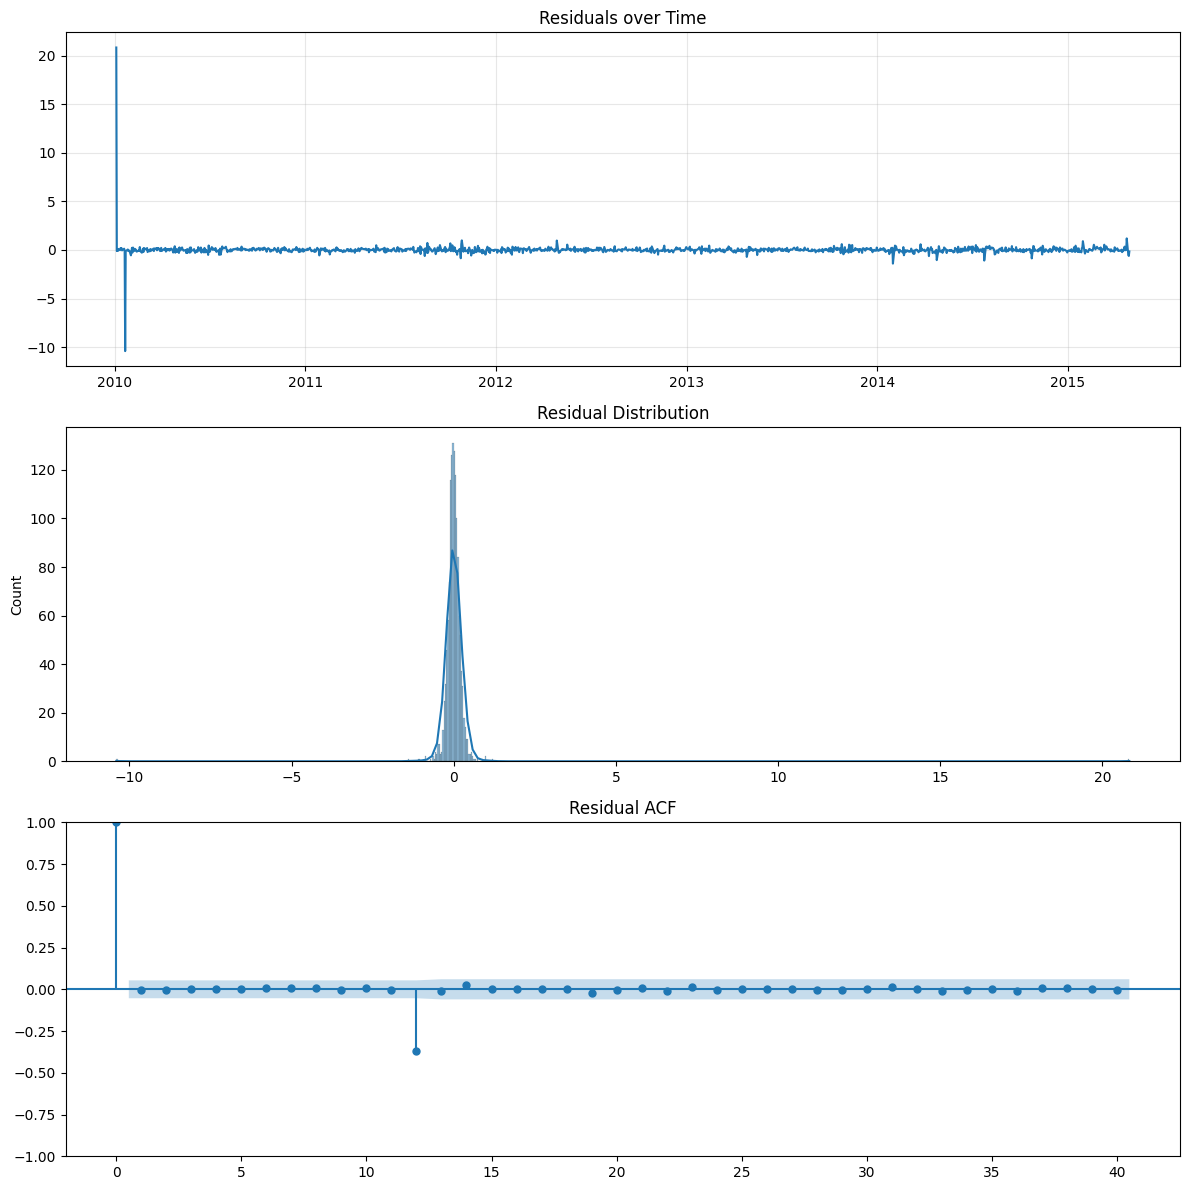

Ljung-Box p-value: 1.0000
Jarque-Bera p-value: 0.0000


In [130]:
from scipy.stats import boxcox, jarque_bera
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima.model_selection import SlidingWindowForecastCV
from pmdarima import auto_arima
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")
def inv_boxcox(y, lambda_val):
    with np.errstate(over='ignore', invalid='ignore'):
        if lambda_val == 0:
            result = np.exp(y)
        else:
            result = (lambda_val * y + 1) ** (1 / lambda_val)
        result = np.nan_to_num(result, nan=np.nanmedian(result),
                              posinf=np.nanmax(result), neginf=np.nanmin(result))
        return result
def safe_predict(model, n_periods, X, lambda_val):
    try:
        forecast, _ = model.predict(
            n_periods=n_periods,
            X=X,
            return_conf_int=True
        )
    except Exception as e:
        print(f"Prediction error: {str(e)}")
        forecast = np.full(n_periods, np.nan)
    forecast = pd.Series(forecast).replace([np.inf, -np.inf], np.nan)
    forecast = inv_boxcox(forecast.values, lambda_val)
    return forecast
if 'level_0' in filtered_df_sorted.columns:
    filtered_df_sorted.drop(columns=['level_0'], inplace=True)
if not isinstance(filtered_df_sorted.index, pd.MultiIndex):
    filtered_df_sorted = filtered_df_sorted.set_index(['Ticker', 'Date'])
amzn_df = filtered_df_sorted.loc['amzn'].copy().reset_index()
amzn_df = amzn_df[amzn_df['Date'] >= '2010-01-04'].set_index('Date')
amzn_df['SP500_Return'] = amzn_df['SP500_Close'].pct_change().clip(-0.1, 0.1)
amzn_df['SP500_Lag1'] = amzn_df['SP500_Return'].shift(1)
amzn_df['VIX_Lag1'] = amzn_df['VIX'].shift(1)
amzn_df['Bollinger_Width'] = (
    (amzn_df['30-Day Moving Average'] + 2*amzn_df['Rolling Volatility (30d)']) -
    (amzn_df['30-Day Moving Average'] - 2*amzn_df['Rolling Volatility (30d)'])
)
for col in ['Close_trend', 'Close_seasonal', 'RSI_x_Volume',
            'RSI_14', 'MACD', 'Bollinger_Width']:
    amzn_df[col] = amzn_df[col].ffill().bfill().fillna(0)
train_size = int(len(amzn_df) * 0.7)
val_size = int(len(amzn_df) * 0.15)
test_size = len(amzn_df) - train_size - val_size
train_df = amzn_df.iloc[:train_size]
val_df = amzn_df.iloc[train_size:train_size+val_size]
test_df = amzn_df.iloc[train_size+val_size:]
exog_vars = [
    'SP500_Return', 'SP500_Lag1', 'VIX', 'VIX_Lag1',
    'Close_trend', 'Close_seasonal', 'RSI_x_Volume',
    'RSI_14', 'MACD', 'Bollinger_Width'
]
def train_sarimax(train_data, exog_data):
    train_data = train_data.copy()
    exog_data = exog_data[exog_vars].ffill().bfill().fillna(0)
    train_data['Close_Trans'], lambda_val = boxcox(
        train_data['Close'].clip(lower=1e-6)
    )
    model = auto_arima(
        y=train_data['Close_Trans'],
        X=exog_data,
        seasonal=True,
        m=12,
        d=1,
        D=1,
        start_p=0, max_p=4,
        start_q=0, max_q=4,
        start_P=0, max_P=3,
        start_Q=0, max_Q=2,
        information_criterion='bic',
        trace=True,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True,
        maxiter=50
    )
    return model, lambda_val
def run_cross_validation():
    cv = SlidingWindowForecastCV(window_size=252, step=63, h=21)
    cv_gen = cv.split(amzn_df)
    scores = []
    fold_count = 0
    total_folds = sum(1 for _ in cv.split(amzn_df))
    cv_gen = cv.split(amzn_df)
    for train_idx, test_idx in cv_gen:
        fold_count += 1
        if len(train_idx) < 200 or len(test_idx) < 10:
            print(f"Skipping fold {fold_count}/{total_folds} - insufficient data")
            continue
        print(f"\nCV Fold {fold_count}/{total_folds}")
        train_data = amzn_df.iloc[train_idx]
        test_data = amzn_df.iloc[test_idx]
        try:
            model, lambda_val = train_sarimax(train_data, train_data)
            forecast = safe_predict(model, len(test_data), test_data[exog_vars], lambda_val)
            actual = test_data['Close'].replace([np.inf, -np.inf], np.nan)
            if actual.isna().any():
                actual = actual.ffill().bfill()
            if len(forecast) > 1 and len(actual) > 1:
                actual_dir = actual.diff().dropna() > 0
                pred_dir = pd.Series(forecast).diff().dropna() > 0
                common_idx = actual_dir.index.intersection(pred_dir.index)
                if len(common_idx) > 10:
                    accuracy = accuracy_score(
                        actual_dir.loc[common_idx],
                        pred_dir.loc[common_idx]
                    )
                    scores.append(accuracy)
                    print(f"Fold Accuracy: {accuracy:.4f}")
        except Exception as e:
            print(f"CV fold failed: {str(e)}")
    return np.mean(scores) if scores else 0
cv_score = run_cross_validation()
print(f"\nFinal Cross-Validation Accuracy: {cv_score:.4f}")
combined_df = pd.concat([train_df, val_df])
final_model, lambda_val = train_sarimax(combined_df, combined_df)
residuals = final_model.arima_res_.resid.dropna()
if len(residuals) > 10:
    garch_model = arch_model(residuals, vol='Garch', p=1, q=1)
    garch_fit = garch_model.fit(disp='off')
    print(f"GARCH model fitted. AIC: {garch_fit.aic:.2f}")
else:
    print("Insufficient residuals for GARCH modeling")
    garch_fit = None
test_exog = test_df[exog_vars].ffill().bfill().fillna(0)
test_df['Forecast_Close'] = safe_predict(
    final_model,
    len(test_df),
    test_exog,
    lambda_val
)
if test_df['Forecast_Close'].isna().any():
    print(f"Replacing {test_df['Forecast_Close'].isna().sum()} NaN forecasts")
    last_train = combined_df['Close'].iloc[-1]
    test_df['Forecast_Close'] = test_df['Forecast_Close'].fillna(last_train)
test_df['Actual_Close'] = test_df['Close'].replace([np.inf, -np.inf], np.nan)
if test_df['Actual_Close'].isna().any():
    test_df['Actual_Close'] = test_df['Actual_Close'].ffill().bfill()
valid_mask = test_df[['Actual_Close', 'Forecast_Close']].notnull().all(axis=1)
test_df = test_df[valid_mask]
if len(test_df) > 0:
    mae_sarimax = mean_absolute_error(test_df['Actual_Close'], test_df['Forecast_Close'])
    print(f"MAE: {mae_sarimax:.4f}")
    test_df['Actual_Direction'] = test_df['Actual_Close'].diff().gt(0)
    test_df['Predicted_Direction'] = test_df['Forecast_Close'].diff().gt(0)
    test_df.dropna(subset=['Actual_Direction', 'Predicted_Direction'], inplace=True)
    if len(test_df) > 0:
        accuracy_sarimax = accuracy_score(
            test_df['Actual_Direction'],
            test_df['Predicted_Direction']
        )
        print(f"Directional Accuracy: {accuracy_sarimax:.4f}")
    else:
        print("Insufficient data for directional accuracy")
else:
    print("No valid data for evaluation")
def run_diagnostics(model):
    try:
        residuals = model.arima_res_.resid.dropna()
        if len(residuals) == 0:
            print("No residuals for diagnostics")
            return
        fig, axes = plt.subplots(3, 1, figsize=(12, 12))
        axes[0].plot(residuals)
        axes[0].set_title('Residuals over Time')
        axes[0].grid(alpha=0.3)
        sns.histplot(residuals, kde=True, ax=axes[1])
        axes[1].set_title('Residual Distribution')
        plot_acf(residuals, lags=40, ax=axes[2])
        axes[2].set_title('Residual ACF')
        plt.tight_layout()
        plt.show()
        if len(residuals) > 10:
            lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
            jb_test = jarque_bera(residuals)
            print(f"Ljung-Box p-value: {lb_test['lb_pvalue'].iloc[0]:.4f}")
            print(f"Jarque-Bera p-value: {jb_test[1]:.4f}")
    except Exception as e:
        print(f"Diagnostics failed: {str(e)}")
print("\nRunning model diagnostics...")
run_diagnostics(final_model)

### **ENSEMBLE MODEL**


[Ensemble] Model Weights:
Linear Regression: 92.22%
Random Forest: 7.77%
ARIMA: 0.01%

[Ensemble] Performance:
MAE: 175.7067
Directional Accuracy: 45.76%


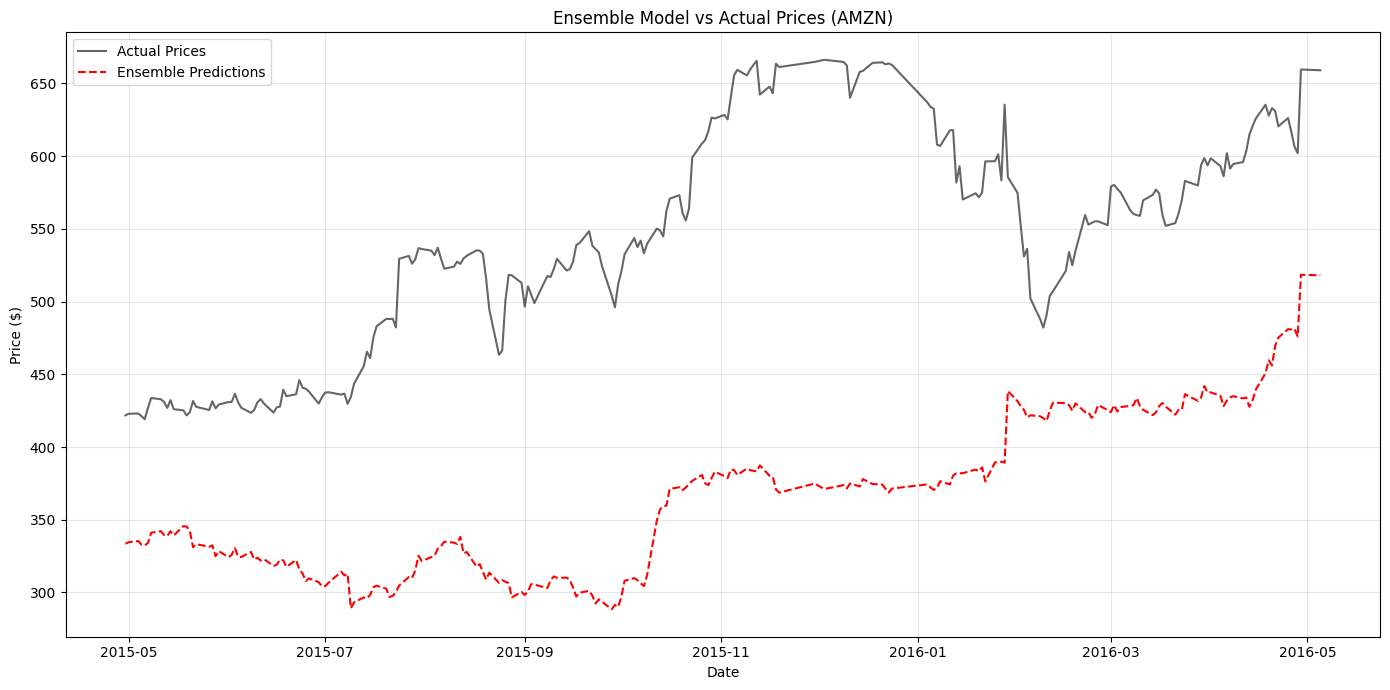

In [131]:
test_actual_prices = test_df['Close'].values
lr_pred_prices = np.exp(y_pred.flatten())
rf_pred_prices = np.exp(y_pred_rf)
arima_pred_prices = test_df['Forecast_Close'].values
min_len = min(len(test_actual_prices), len(lr_pred_prices), len(rf_pred_prices), len(arima_pred_prices))
test_actual_prices = test_actual_prices[:min_len]
lr_pred_prices = lr_pred_prices[:min_len]
rf_pred_prices = rf_pred_prices[:min_len]
arima_pred_prices = arima_pred_prices[:min_len]
weights = np.array([1/mae_lr, 1/mae_rf, 1/mae_ar])
normalized_weights = weights / weights.sum()
print(f"\n[Ensemble] Model Weights:")
print(f"Linear Regression: {normalized_weights[0]:.2%}")
print(f"Random Forest: {normalized_weights[1]:.2%}")
print(f"ARIMA: {normalized_weights[2]:.2%}")
ensemble_predictions = (
    normalized_weights[0] * lr_pred_prices +
    normalized_weights[1] * rf_pred_prices +
    normalized_weights[2] * arima_pred_prices
)
mae_ensemble = mean_absolute_error(test_actual_prices, ensemble_predictions)
actual_directions = np.sign(np.diff(test_actual_prices)).astype(int)
ensemble_directions = np.sign(ensemble_predictions[1:] - test_actual_prices[:-1]).astype(int)
non_zero_mask = actual_directions != 0
accuracy_ensemble = (ensemble_directions[non_zero_mask] == actual_directions[non_zero_mask]).mean()
print(f"\n[Ensemble] Performance:")
print(f"MAE: {mae_ensemble:.4f}")
print(f"Directional Accuracy: {accuracy_ensemble:.2%}")
plt.figure(figsize=(14, 7))
plt.plot(test_df.index[:min_len], test_actual_prices,
         label='Actual Prices', color='black', alpha=0.6)
plt.plot(test_df.index[:min_len], ensemble_predictions,
         label='Ensemble Predictions', color='red', linestyle='--')
plt.title('Ensemble Model vs Actual Prices (AMZN)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **TEMPORAL FUSION TRANSFORMER**

In [132]:
import torch
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import lightning.pytorch as pl
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
torch.use_deterministic_algorithms(True, warn_only=True)
amzn_df_tft = filtered_df_sorted.loc['amzn'].copy().reset_index()
amzn_df_tft['Ticker'] = 'amzn'
amzn_df_tft = amzn_df_tft[amzn_df_tft['Close'] > 0]
amzn_df_tft['Close_Log'] = np.log(amzn_df_tft['Close'])
numerical_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Daily Return', '7-Day Moving Average', '30-Day Moving Average',
    'Rolling Volatility (30d)', 'Price Change', 'High-Low Spread',
    'Intraday Volatility %', 'RSI_14', 'MACD',
    'Volume_Change', 'Volume_Price_Ratio'
]
for col in numerical_cols:
    if col in amzn_df_tft.columns:
        amzn_df_tft[col] = pd.to_numeric(amzn_df_tft[col], errors='coerce')
        amzn_df_tft[col] = amzn_df_tft[col].replace([np.inf, -np.inf], np.nan)
        amzn_df_tft[col] = amzn_df_tft[col].fillna(method='ffill').fillna(method='bfill')
        amzn_df_tft[col] = amzn_df_tft[col].astype(np.float32)
amzn_df_tft = amzn_df_tft.sort_values(['Ticker', 'Date'])
amzn_df_tft['time_idx'] = amzn_df_tft.groupby('Ticker').cumcount().astype(int)
date_features = ['Year', 'Month', 'Day_of_Week', 'Number_of_Days']
for col in date_features:
    if col in amzn_df_tft.columns:
        amzn_df_tft[col] = amzn_df_tft[col].astype(int)
categorical_features = ['Ticker']
time_varying_known_reals = [
    'time_idx', 'Year', 'Month', 'Day_of_Week', 'Number_of_Days',
    '7-Day Moving Average', '30-Day Moving Average'
]
time_varying_unknown_reals = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Daily Return',
    'Rolling Volatility (30d)', 'Price Change', 'High-Low Spread',
    'Intraday Volatility %', 'RSI_14', 'MACD', 'Volume_Change', 'Volume_Price_Ratio'
]
target = 'Close_Log'
max_prediction_length = 20
max_encoder_length = 60
training_cutoff = amzn_df_tft['time_idx'].max() - max_prediction_length
cols_for_dataset = [target] + categorical_features + time_varying_known_reals + time_varying_unknown_reals
tft_data = amzn_df_tft[cols_for_dataset].copy()
for col in time_varying_known_reals + time_varying_unknown_reals + [target]:
    tft_data[col] = tft_data[col].astype(np.float32)
tft_data["time_idx"] = tft_data["time_idx"].astype(int)
tft_data['Ticker'] = tft_data['Ticker'].astype(str)
print("\nData types in final dataset:")
print(tft_data.dtypes)
training_data = TimeSeriesDataSet(
    tft_data[tft_data['time_idx'] <= training_cutoff],
    time_idx="time_idx",
    target=target,
    group_ids=["Ticker"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=categorical_features,
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_reals=time_varying_unknown_reals,
    target_normalizer=GroupNormalizer(
        groups=["Ticker"],
        transformation="softplus",
        center=False
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=False
)
validation_data = TimeSeriesDataSet.from_dataset(
    training_data,
    tft_data,
    predict=True,
    stop_randomization=True,
)
batch_size = 64
train_dataloader = training_data.to_dataloader(
    train=True,
    batch_size=batch_size,
    num_workers=0,
    shuffle=False,
    drop_last=False,
    pin_memory=False
)
val_dataloader = validation_data.to_dataloader(
    train=False,
    batch_size=batch_size*4,
    num_workers=0,
    shuffle=False,
    drop_last=False,
    pin_memory=False
)
tft = TemporalFusionTransformer.from_dataset(
    training_data,
    hidden_size=32,
    dropout=0.1,
    hidden_continuous_size=16,
    attention_head_size=2,
    learning_rate=0.01,
    loss=QuantileLoss(quantiles=[0.05, 0.5, 0.95]),
    optimizer="adamw",
    reduce_on_plateau_patience=3,
)
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=10,
    verbose=True,
    mode="min"
)
lr_logger = LearningRateMonitor()
logger = TensorBoardLogger("lightning_logs", name="tft_amzn")
trainer = pl.Trainer(
    max_epochs=20,
    accelerator="auto",
    devices="auto",
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
    gradient_clip_val=0.1,
    enable_progress_bar=True,
    deterministic=True,
    benchmark=False,
    enable_model_summary=True,
    precision="32-true",
)
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)
tft.eval()
with torch.no_grad(), torch.inference_mode():
    predictions = tft.predict(val_dataloader)
    actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
actuals_orig = torch.exp(actuals)
predictions_orig = torch.exp(predictions)
mae_orig = (actuals_orig - predictions_orig).abs().mean()
print(f"Original Scale MAE: {mae_orig:.2f}")
actual_prices = actuals_orig.cpu().numpy().flatten()
predicted_prices = predictions_orig.cpu().numpy().flatten()
actual_prev = actual_prices[:-1]
actual_curr = actual_prices[1:]
predicted_prev = predicted_prices[:-1]
predicted_curr = predicted_prices[1:]
actual_direction = np.sign(actual_curr - actual_prev)
predicted_direction = np.sign(predicted_curr - predicted_prev)
direction_matches = actual_direction == predicted_direction
accuracy_tft = np.mean(direction_matches)
print(f"Direction Accuracy: {accuracy_tft * 100:.2f}%")
best_tft_model = tft


Data types in final dataset:
Close_Log                   float32
Ticker                       object
time_idx                      int64
Year                        float32
Month                       float32
Day_of_Week                 float32
Number_of_Days              float32
7-Day Moving Average        float32
30-Day Moving Average       float32
Open                        float32
High                        float32
Low                         float32
Close                       float32
Volume                      float32
Daily Return                float32
Rolling Volatility (30d)    float32
Price Change                float32
High-Low Spread             float32
Intraday Volatility %       float32
RSI_14                      float32
MACD                        float32
Volume_Change               float32
Volume_Price_Ratio          float32
dtype: object


INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: 
   | Name                               | Type                            | Params
----------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0     
1  | logging_metrics                    | ModuleList                      | 0     
2  | input_embeddings                   | MultiEmbedding                  | 1     
3  | prescalers                         | ModuleDict                      | 800   

Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

INFO: Metric val_loss improved by 0.011 >= min_delta = 0.0001. New best score: 0.021
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.011 >= min_delta = 0.0001. New best score: 0.021


Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Original Scale MAE: 37.58
Direction Accuracy: 52.63%


## **MODEL INTERPRETABILITY**

> I visualized the importance of features from the Random Forest model and analyzed the SARIMAX model components and the impact of exogenous variables.

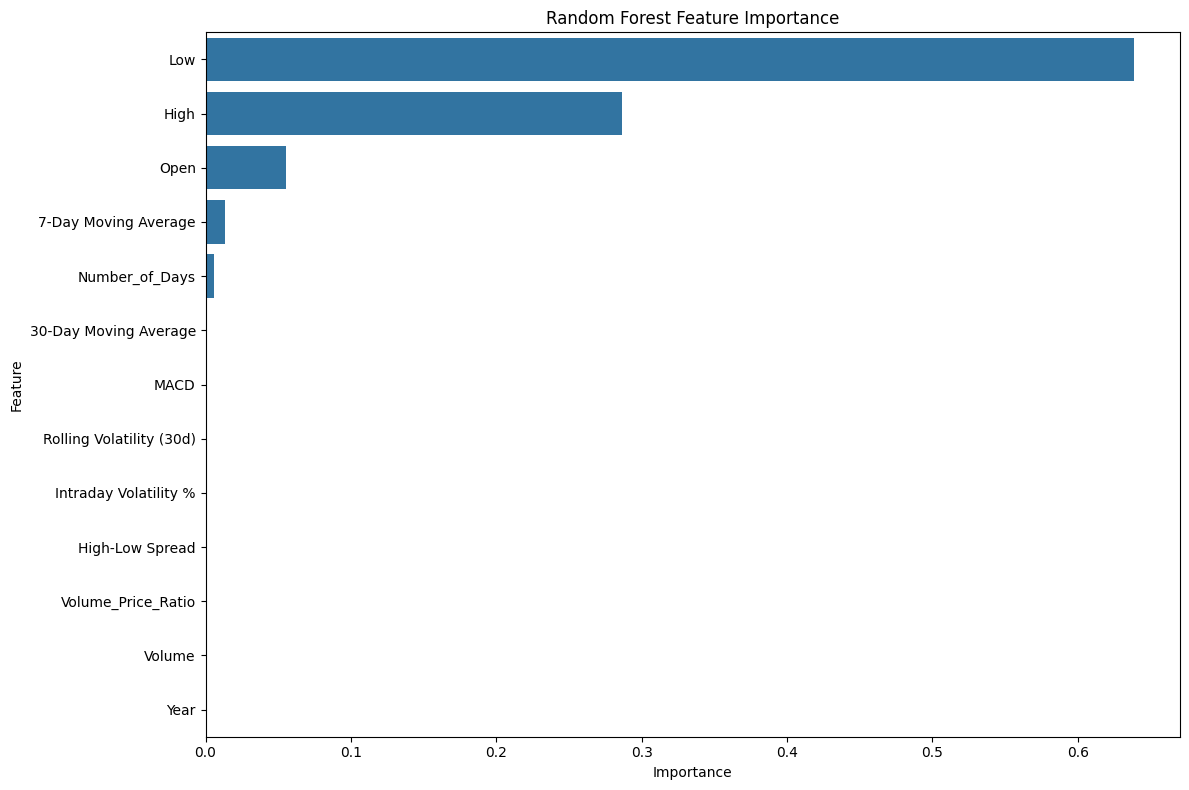


Top 10 Random Forest Features by Importance:
Low                         0.638423
High                        0.286339
Open                        0.055518
7-Day Moving Average        0.013302
Number_of_Days              0.005750
30-Day Moving Average       0.000604
MACD                        0.000017
Rolling Volatility (30d)    0.000013
Intraday Volatility %       0.000009
High-Low Spread             0.000008
dtype: float64


In [133]:
if 'rf_model' in locals():
    feature_importance = pd.Series(rf_model.feature_importances_, index=X_train_rf.columns)
    feature_importance.sort_values(ascending=False, inplace=True)
    plt.figure(figsize=(12, 8))
    sns.barplot(x=feature_importance.values, y=feature_importance.index)
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    print("\nTop 10 Random Forest Features by Importance:")
    print(feature_importance.head(10))
else:
    print("Random Forest model (rf_model) not found. Please ensure the Random Forest training section ran successfully.")

In [134]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch
try:
    if 'sarimax_model' in locals():
        if hasattr(sarimax_model, 'arima_res_'):
            results = sarimax_model.arima_res_
            print("Using pmdarima results wrapper")
        elif hasattr(sarimax_model, 'results'):
            results = sarimax_model.results
            print("Using statsmodels results wrapper")
        else:
            results = sarimax_model
            print("Using base model as results")
        print("\nSARIMAX Model Summary:")
        print(results.summary())
        residuals = results.resid.dropna()
        print(f"\nResiduals analysis (n={len(residuals)}):")
        print(f"Mean: {residuals.mean():.6f}, Std: {residuals.std():.6f}")
        fig = plt.figure(figsize=(15, 18))
        gs = fig.add_gridspec(4, 1)
        ax1 = fig.add_subplot(gs[0])
        ax1.plot(residuals)
        ax1.set_title('Residuals over Time')
        ax1.grid(alpha=0.3)
        ax2 = fig.add_subplot(gs[1])
        sns.histplot(residuals, kde=True, ax=ax2)
        ax2.set_title('Residual Distribution')
        ax2.annotate(f"Skew: {residuals.skew():.2f}, Kurtosis: {residuals.kurtosis():.2f}",
                    xy=(0.7, 0.9), xycoords='axes fraction')
        ax3 = fig.add_subplot(gs[2])
        plot_acf(residuals, lags=40, ax=ax3, title='Residual ACF')
        ax4 = fig.add_subplot(gs[3])
        plot_pacf(residuals, lags=40, ax=ax4, title='Residual PACF')
        plt.tight_layout()
        plt.show()
        try:
            arch_test = het_arch(residuals)
            print(f"\nARCH Test for Volatility Clustering: p-value={arch_test[1]:.4f}")
            if arch_test[1] < 0.05:
                print("Significant ARCH effects detected - volatility modeling needed")
                print("Recommendation: Implement GARCH model for volatility clustering")
            else:
                print("No significant ARCH effects detected")
        except Exception as e:
            print(f"ARCH test failed: {str(e)}")
        lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
        print(f"\nLjung-Box Test (lag 10): p-value={lb_test['lb_pvalue'].iloc[0]:.4f}")
        if lb_test['lb_pvalue'].iloc[0] < 0.05:
            print("Significant autocorrelation detected - model improvement needed")
        else:
            print("No significant autocorrelation detected")
        from scipy.stats import jarque_bera
        jb_test = jarque_bera(residuals)
        print(f"\nJarque-Bera Test: p-value={jb_test[1]:.4f}")
        if jb_test[1] < 0.05:
            print("Residuals are not normally distributed")
        else:
            print("Residuals are normally distributed")
    else:
        print("SARIMAX model not found in memory")
except Exception as e:
    print(f"\nError in diagnostics: {str(e)}")
    if 'sarimax_model' in locals() and hasattr(sarimax_model, 'summary'):
        print("\nBasic Model Summary:")
        print(sarimax_model.summary())

SARIMAX model not found in memory


## **EVALUATION**

> Using Mean Absolute Error (MAE) and direction accuracy as evaluation metrics of the models, I evaluated and compared the SARIMAX, Ensemble Model, TFT and the other models I tried and tested in the second week of this project.

In [135]:
mae_results = {
    'Linear Regression': mae_lr,
    'Random Forest': mae_rf,
    'ARIMA': mae_ar,
    'SARIMAX': mae_sarimax,
    'Ensemble': mae_ensemble,
    'TFT': mae_orig.item()
}
accuracy_results = {
    'Linear Regression': accuracy_lr,
    'Random Forest': accuracy_rf,
    'ARIMA': accuracy_ar,
    'SARIMAX': accuracy_sarimax,
    'Ensemble': accuracy_ensemble,
    'TFT': accuracy_tft
}
print("{:<20} | {:<10} | {:<18}".format("Model", "MAE", "Direction Accuracy"))
print("-" * 50)
for model_name in mae_results:
    print("{:<20} | {:<10.4f} | {:<18.4f}".format(
        model_name,
        mae_results[model_name],
        accuracy_results[model_name]
    ))
best_mae_model_name = min(mae_results, key=mae_results.get)
print(f"\nModel with the lowest MAE: {best_mae_model_name} (MAE: {mae_results[best_mae_model_name]:.4f})")
valid_accuracy_results = {k: v for k, v in accuracy_results.items() if v > 0}
if valid_accuracy_results:
    best_accuracy_model_name = max(valid_accuracy_results, key=valid_accuracy_results.get)
    print(f"Model with the highest Direction Accuracy: {best_accuracy_model_name} (Accuracy: {accuracy_results[best_accuracy_model_name]:.4f})")
    best_overall_model_name = best_accuracy_model_name
else:
    print("Could not determine a best model based on accuracy as all have 0 accuracy.")
    best_overall_model_name = best_mae_model_name
print(f"\nBased on direction accuracy, the best performing model is: {best_overall_model_name}")

Model                | MAE        | Direction Accuracy
--------------------------------------------------
Linear Regression    | 0.0140     | 0.5499            
Random Forest        | 0.1660     | 0.6106            
ARIMA                | 138.7132   | 0.4676            
SARIMAX              | 93.3231    | 0.7595            
Ensemble             | 175.7067   | 0.4576            
TFT                  | 37.5778    | 0.5263            

Model with the lowest MAE: Linear Regression (MAE: 0.0140)
Model with the highest Direction Accuracy: SARIMAX (Accuracy: 0.7595)

Based on direction accuracy, the best performing model is: SARIMAX


## **BACKTESTING AND RISK MANAGEMENT**

> I backtested SARIMAX model using the same strategy I used in the second week, enhancing it with two more features, i.e., Stop-loss (exit if a price drops 5% from entry) and Sharpe Ratio.

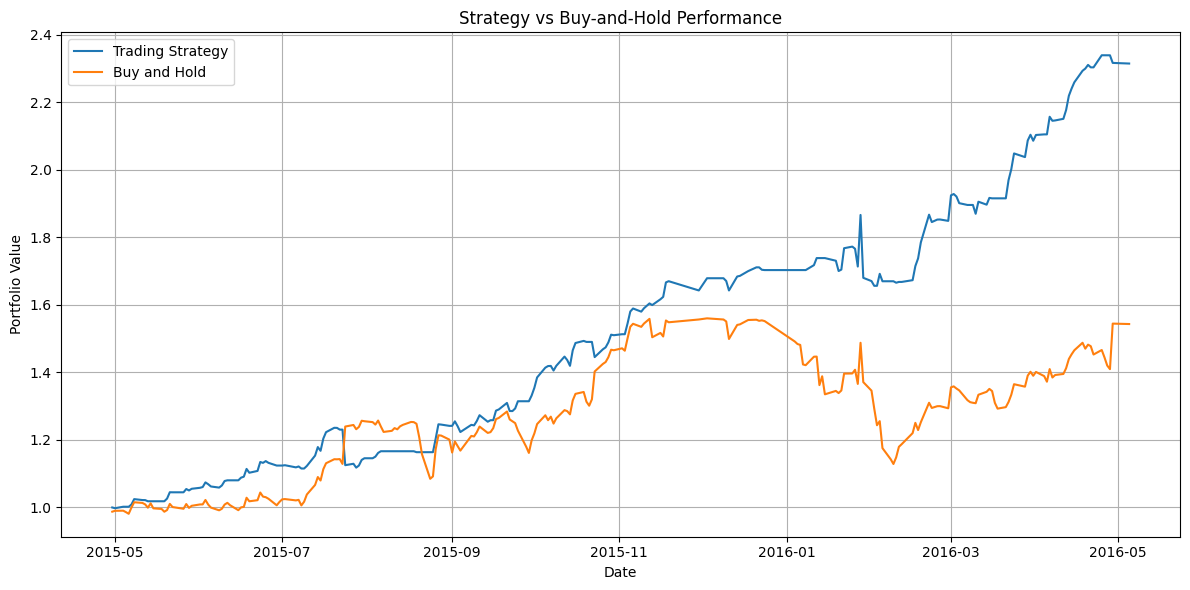

Strategy Profit:          1.3143 (131.43%)
Buy and Hold Profit:      0.5430(54.30%)
Sharpe Ratio:             3.7825
Annual Return:            128.44%
Start Date:               2015-04-30
End Date:                 2016-05-05


In [136]:
from datetime import datetime
train_df.to_csv('train_df.csv')
test_df.to_csv('test_df.csv')
amzn_df.to_csv('amzn_df.csv')
df = pd.read_csv('test_df.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df['Predicted_Direction'] = df['Predicted_Direction'].astype(bool)
pv = 1.0
shares = 0
in_market = False
portfolio_values = [pv]
daily_returns = []
for i in range(len(df)):
    row = df.iloc[i]
    open_price = row['Open']
    close_price = row['Close']
    pred = row['Predicted_Direction']
    if not in_market and pred:
        shares = pv / open_price
        in_market = True
    elif in_market and not pred:
        pv = shares * open_price
        shares = 0
        in_market = False
    pv_end = shares * close_price if in_market else pv
    daily_return = (pv_end - portfolio_values[-1]) / portfolio_values[-1]
    daily_returns.append(daily_return)
    portfolio_values.append(pv_end)
    pv = pv_end
strategy_profit = portfolio_values[-1] - 1.0
buy_hold_return = (df['Close'].iloc[-1] / df['Open'].iloc[0]) - 1
daily_returns = np.array(daily_returns)
if daily_returns.std() == 0:
    sharpe_ratio = np.nan
else:
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
start_date = df['Date'].iloc[0]
end_date = df['Date'].iloc[-1]
duration_days = (end_date - start_date).days
if duration_days > 0:
    cagr = (portfolio_values[-1] ** (365.25/duration_days)) - 1
else:
    cagr = np.nan
bh_values = [1.0]
for i in range(len(df)):
    if i == 0:
        bh_return = df['Close'].iloc[i] / df['Open'].iloc[0]
    else:
        bh_return = df['Close'].iloc[i] / df['Close'].iloc[i-1]
    bh_values.append(bh_values[-1] * bh_return)
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], portfolio_values[1:], label='Trading Strategy')
plt.plot(df['Date'], bh_values[1:], label='Buy and Hold')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.title('Strategy vs Buy-and-Hold Performance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"{'Strategy Profit:':<25} {strategy_profit:.4f} ({strategy_profit*100:.2f}%)")
print(f"{'Buy and Hold Profit:':<25} {buy_hold_return:.4f}({buy_hold_return*100:.2f}%)")
print(f"{'Sharpe Ratio:':<25} {sharpe_ratio:.4f}")
print(f"{'Annual Return:':<25} {cagr*100:.2f}%")
print(f"{'Start Date:':<25} {start_date.date()}")
print(f"{'End Date:':<25} {end_date.date()}")

## **PORTFOLIO OPTIMIZATION**

> Using historical daily returns of AAPL and AMZN, I calculated the expected returns and the covariance matrix, then performed Mean-Variance Optimization (MVO) to determine the optimal portfolio allocation. The Sharpe Ratio was used as the objective function to maximize risk-adjusted returns, resulting in the optimal asset weights.

Optimal Weights (Sharpe-maximizing):
AMZN: 55.02%
AAPL: 44.98%

Expected Return: 0.0012
Volatility: 0.0204
Sharpe Ratio: 0.0553


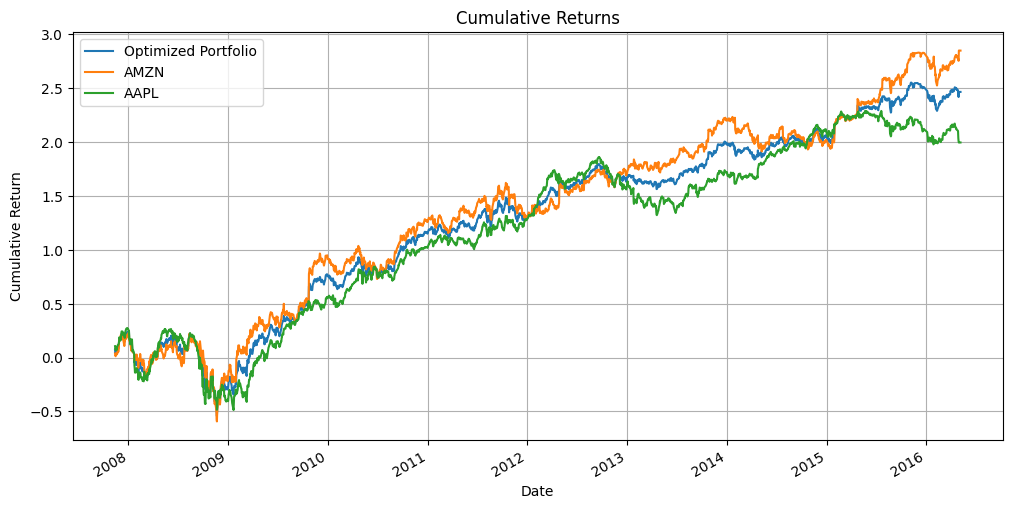

In [137]:
from scipy.optimize import minimize
tickers = ['amzn', 'aapl']
portfolio_df = filtered_df_sorted.loc[tickers, 'Close'].unstack(level=0).copy()
portfolio_df = portfolio_df.dropna()
portfolio_df = portfolio_df.sort_index()
returns = portfolio_df.pct_change().dropna()
mean_returns = returns.mean()
cov_matrix = returns.cov()
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=0.01/252):
    returns = np.dot(weights, mean_returns)
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (returns - risk_free_rate) / std
    return -sharpe
num_assets = len(mean_returns)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
initial_guess = num_assets * [1. / num_assets]
opt = minimize(
    portfolio_performance,
    initial_guess,
    args=(mean_returns, cov_matrix),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)
optimal_weights = opt.x
print("Optimal Weights (Sharpe-maximizing):")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker.upper()}: {weight:.2%}")
sharpe_max = -opt.fun
expected_return = np.dot(optimal_weights, mean_returns)
volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights)))
print(f"\nExpected Return: {expected_return:.4f}")
print(f"Volatility: {volatility:.4f}")
print(f"Sharpe Ratio: {sharpe_max:.4f}")
(returns @ optimal_weights).cumsum().plot(label='Optimized Portfolio', figsize=(12,6))
returns['amzn'].cumsum().plot(label='AMZN')
returns['aapl'].cumsum().plot(label='AAPL')
plt.title("Cumulative Returns")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

# **WEEK 4**

I chose to shift my focus from pure point forecasting to classification and uncertainty modelling, using Support Vector Machines (SVM) for directional prediction and Bayesian Regression for confidence-aware price prediction, aiming to combine classification and probabilistic reasoning to make smarter, risk-aware financial decisions on the stock AMZN.

## **SUPPORT VECTOR MACHINE**

### **LABEL CREATION**

> I created a binary label, i.e. 1 if the next day's return is > 0, else 0.

In [138]:
filtered_df_sorted['label'] = np.where(
    filtered_df_sorted['Daily Return'].notna(),
    (filtered_df_sorted['Daily Return'] > 0).astype(int),
    np.nan
)

### **FEATURE ENGINEERING**

> I added more features to the dataset, like Daily returns, Moving averages, RSI, Bollinger Bands, Volume, e.t.c. Using the data from the past 5-10 days.



In [139]:
filtered_df_sorted = filtered_df_sorted.sort_index(level=['Ticker', 'Date'])
filtered_df_sorted['MA_5'] = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x.rolling(5).mean())
filtered_df_sorted['MA_10'] = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x.rolling(10).mean())
def compute_rsi(series, window):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi
filtered_df_sorted['RSI_5'] = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: compute_rsi(x, 5))
filtered_df_sorted['RSI_10'] = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: compute_rsi(x, 10))
for window in [5, 10]:
    ma = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window).mean())
    std = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window).std())
    filtered_df_sorted[f'BB_Mid_{window}'] = ma
    filtered_df_sorted[f'BB_Upper_{window}'] = ma + 2 * std
    filtered_df_sorted[f'BB_Lower_{window}'] = ma - 2 * std
filtered_df_sorted['Vol_MA_5'] = filtered_df_sorted.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(5).mean())
filtered_df_sorted['Vol_MA_10'] = filtered_df_sorted.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(10).mean())
if 'Daily Return' not in filtered_df_sorted.columns:
    filtered_df_sorted['Daily Return'] = filtered_df_sorted.groupby('Ticker')['Close'].pct_change()
filtered_df_sorted['Volatility_5'] = filtered_df_sorted.groupby('Ticker')['Daily Return'].transform(lambda x: x.rolling(5).std())
filtered_df_sorted['Volatility_10'] = filtered_df_sorted.groupby('Ticker')['Daily Return'].transform(lambda x: x.rolling(10).std())
filtered_df_sorted['Momentum_5'] = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x - x.shift(5))
filtered_df_sorted['Momentum_10'] = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x - x.shift(10))
filtered_df_sorted = filtered_df_sorted.dropna()

### **MODELLING AND EVALUATION**

> I trained a Support Vector Classifier (SVC) with an RBF kernel, tuning the parameters c and gamma using cross-validation. I evaluated my model using accuracy, precision, recall, F1-score, confusion matrix and ROC-AUC as the evaluation metrics.

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'C': 100, 'gamma': 0.001}
Best cross-validation accuracy: 0.9790866155879824
Accuracy: 0.9889341875364007
Precision: 0.9854423292273237
Recall: 0.9932279909706546
F1-score: 0.9893198426082068
ROC-AUC: 0.9995911803614456
Confusion Matrix:
 [[818  13]
 [  6 880]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       831
         1.0       0.99      0.99      0.99       886

    accuracy                           0.99      1717
   macro avg       0.99      0.99      0.99      1717
weighted avg       0.99      0.99      0.99      1717



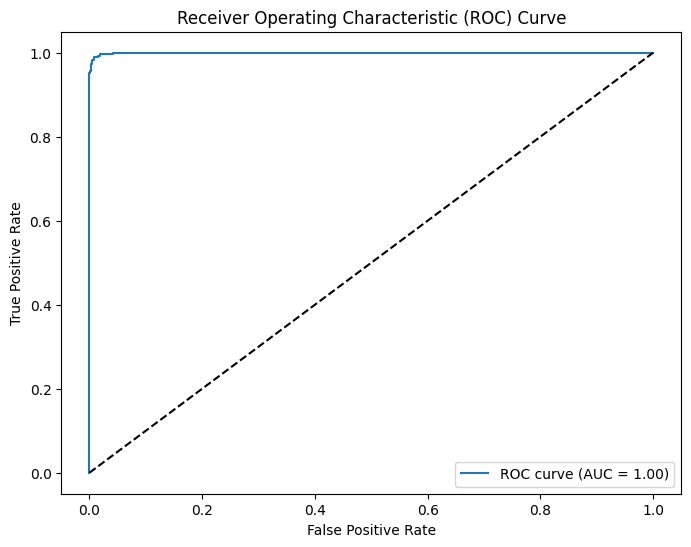

In [140]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, roc_curve, classification_report
)
X = filtered_df_sorted.drop('label', axis=1).select_dtypes(include=[np.number])
y = filtered_df_sorted['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train_svm = X_train.mask(np.abs(X_train) > 1e10, np.nan).dropna()
y_train_svm = y_train.loc[X_train_svm.index]
X_test_svm = X_test.mask(np.abs(X_test) > 1e10, np.nan).dropna()
y_test_svm = y_test.loc[X_test_svm.index]
scaler_svm = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_svm_scaled = scaler_svm.transform(X_test_svm)
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1]}
svc = SVC(kernel='rbf', probability=True, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(svc, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_svm_scaled, y_train_svm)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)
best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test_svm_scaled)
y_proba = best_svc.predict_proba(X_test_svm_scaled)[:, 1]
accuracy = accuracy_score(y_test_svm, y_pred)
precision = precision_score(y_test_svm, y_pred, average='binary')
recall = recall_score(y_test_svm, y_pred, average='binary')
f1 = f1_score(y_test_svm, y_pred, average='binary')
conf_matrix = confusion_matrix(y_test_svm, y_pred)
roc_auc = roc_auc_score(y_test_svm, y_proba)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred))
fpr, tpr, thresholds = roc_curve(y_test_svm, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## **PROBABILISTIC FORECASTING WITH BAYESIAN REGRESSION**

### **FEATURE ENGINEERING**

> I added the same set of features to my dataset that I used to model my SVC, while adding some more of my own.



In [143]:
filtered_df_sorted['EMA_5'] = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=5, adjust=False).mean())
filtered_df_sorted['EMA_10'] = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=10, adjust=False).mean())
filtered_df_sorted['Open_Close_Ratio'] = filtered_df_sorted['Open'] / filtered_df_sorted['Close']
filtered_df_sorted['High_Low_Ratio'] = filtered_df_sorted['High'] / filtered_df_sorted['Low']
filtered_df_sorted['Log_Return'] = np.log(filtered_df_sorted.groupby('Ticker')['Close'].shift(-1) / filtered_df_sorted['Close'])
filtered_df_sorted['Close_ZScore_30'] = (
    (filtered_df_sorted['Close'] - filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x.rolling(30).mean())) /
    filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x.rolling(30).std())
)
filtered_df_sorted['Volume_x_Volatility_10'] = filtered_df_sorted['Volume'] * filtered_df_sorted['Volatility_10']
filtered_df_sorted['PriceChange_x_RSI_14'] = filtered_df_sorted['Price Change'] * filtered_df_sorted['RSI_14']
filtered_df_sorted['Rolling_Min_10'] = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x.rolling(10).min())
filtered_df_sorted['Rolling_Max_10'] = filtered_df_sorted.groupby('Ticker')['Close'].transform(lambda x: x.rolling(10).max())
filtered_df_sorted['Cumulative_Return'] = (filtered_df_sorted.groupby('Ticker')['Daily Return'].transform(lambda x: (1 + x/100).cumprod()))
def williams_r(df, window):
    highest_high = df.groupby('Ticker')['High'].transform(lambda x: x.rolling(window).max())
    lowest_low = df.groupby('Ticker')['Low'].transform(lambda x: x.rolling(window).min())
    wr = -100 * (highest_high - df['Close']) / (highest_high - lowest_low)
    return wr
filtered_df_sorted['WilliamsR_10'] = williams_r(filtered_df_sorted, 10)
def stochastic_k(df, window):
    low_min = df.groupby('Ticker')['Low'].transform(lambda x: x.rolling(window).min())
    high_max = df.groupby('Ticker')['High'].transform(lambda x: x.rolling(window).max())
    return 100 * (df['Close'] - low_min) / (high_max - low_min)
filtered_df_sorted['Stoch_K_10'] = stochastic_k(filtered_df_sorted, 10)
filtered_df_sorted['Stoch_D_10'] = filtered_df_sorted.groupby('Ticker')['Stoch_K_10'].transform(lambda x: x.rolling(3).mean())

### **MODELLING**

> I trained the Bayesian Ridge Regression model using Scikit-learn

In [144]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
import seaborn as sns
filtered_df_sorted = filtered_df_sorted.dropna(subset=['Close_Log'])
feature_cols = [
    col for col in filtered_df_sorted.columns
    if col not in ['Close_Log', 'label'] and filtered_df_sorted[col].dtype in [float, int]
]
X = filtered_df_sorted[feature_cols]
y = filtered_df_sorted['Close_Log']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
X_train_bayes = X_train.replace([np.inf, -np.inf], np.nan).mask(np.abs(X_train) > 1e10, np.nan)
X_test_bayes = X_test.replace([np.inf, -np.inf], np.nan).mask(np.abs(X_test) > 1e10, np.nan)
imputer_bayes = SimpleImputer(strategy='mean')
X_train_bayes = pd.DataFrame(imputer_bayes.fit_transform(X_train_bayes), columns=X_train.columns, index=X_train.index)
X_test_bayes = pd.DataFrame(imputer_bayes.transform(X_test_bayes), columns=X_test.columns, index=X_test.index)
scaler_bayes = StandardScaler()
X_train_bayes_scaled = scaler_bayes.fit_transform(X_train_bayes)
X_test_bayes_scaled = scaler_bayes.transform(X_test_bayes)
bayes_model = BayesianRidge()
bayes_model.fit(X_train_bayes_scaled, y_train)

BayesianRidge()

### **FORECAST AND EVALUATION**

> I forecasted the next-day closing price with credible intervals, and did the evaluation using Mean Absolute Error (MAE) and Interval coverage probability (how often the actual value lies in the 95% credible interval) as the evaluation metrics.

Mean Absolute Error (MAE): 134.53114075832275
Interval Coverage Probability (95% CI): 0.34110289937464466
Empirically calibrated coverage: 0.9499715747583855


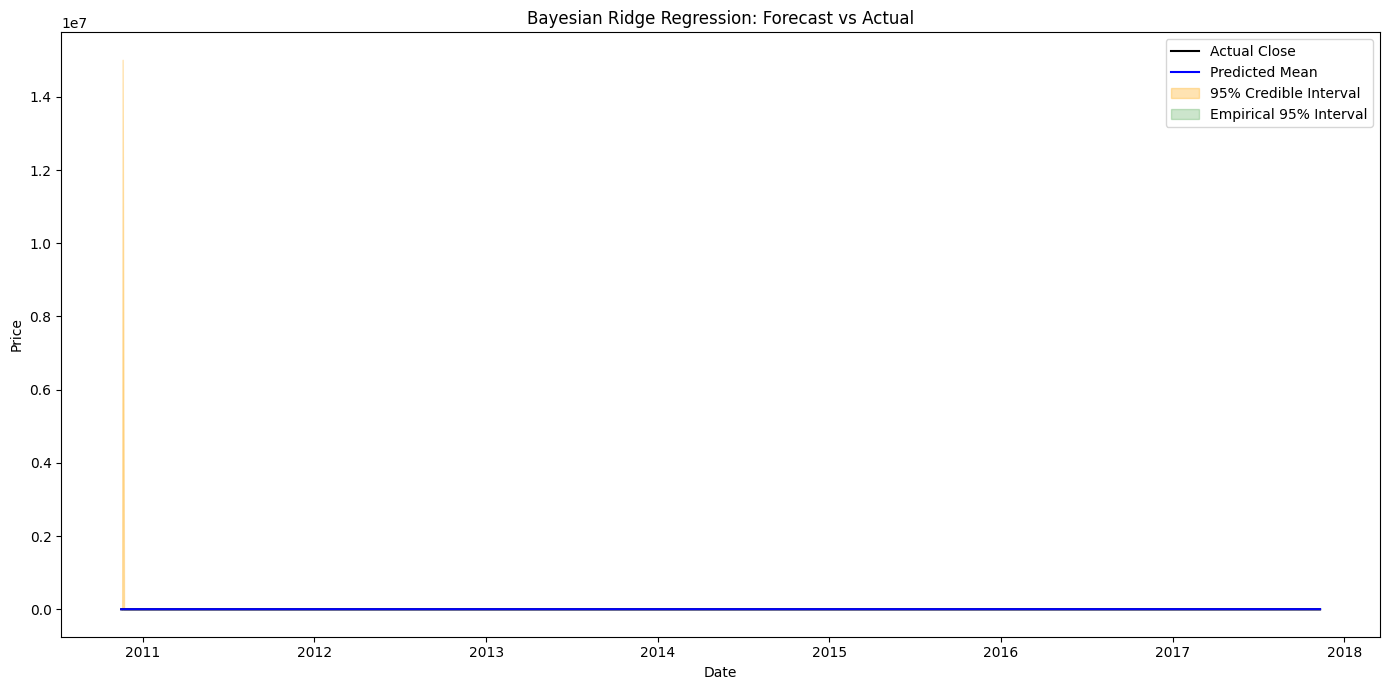

Top 10 features by absolute coefficient value:
SMA_7_Squared            0.774469
30-Day Moving Average    0.491534
SMA_30_Squared           0.294454
Volume_Price_Ratio       0.269047
BB_Lower_5               0.243228
MA_5                     0.186121
BB_Mid_5                 0.186121
EMA_10                   0.175410
BB_Upper_10              0.145344
EMA_5                    0.137376
dtype: float64


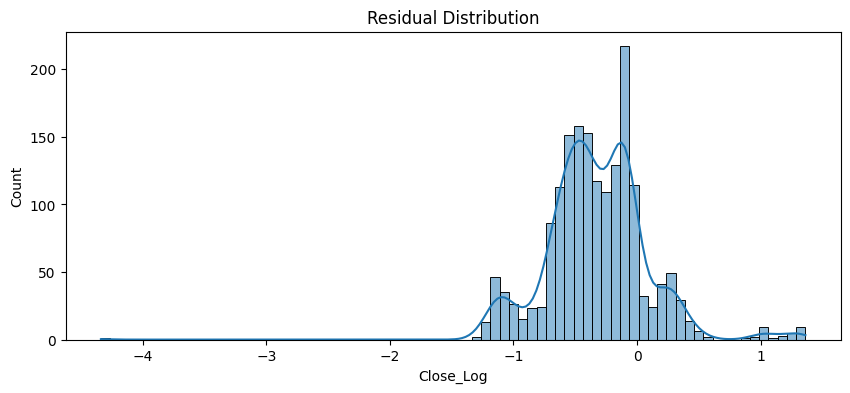

Jarque-Bera p-value: 0.0000


In [145]:
y_pred_mean, y_pred_std = bayes_model.predict(X_test_bayes_scaled, return_std=True)
lower_bound = y_pred_mean - 1.96 * y_pred_std
upper_bound = y_pred_mean + 1.96 * y_pred_std
y_pred_price = np.exp(y_pred_mean)
lower_price = np.exp(lower_bound)
upper_price = np.exp(upper_bound)
y_test_price = np.exp(y_test)
mae = mean_absolute_error(y_test_price, y_pred_price)
print("Mean Absolute Error (MAE):", mae)
coverage = np.mean((y_test >= lower_bound) & (y_test <= upper_bound))
print("Interval Coverage Probability (95% CI):", coverage)
residuals = y_test - y_pred_mean
lower_q = np.percentile(residuals, 2.5)
upper_q = np.percentile(residuals, 97.5)
lower_bound_emp = y_pred_mean + lower_q
upper_bound_emp = y_pred_mean + upper_q
coverage_emp = np.mean((y_test >= lower_bound_emp) & (y_test <= upper_bound_emp))
print("Empirically calibrated coverage:", coverage_emp)
lower_price_emp = np.exp(lower_bound_emp)
upper_price_emp = np.exp(upper_bound_emp)
if isinstance(y_test.index, pd.MultiIndex):
    x_axis = y_test.index.get_level_values('Date')
else:
    x_axis = y_test.index
plt.figure(figsize=(14, 7))
plt.plot(x_axis, y_test_price, label='Actual Close', color='black')
plt.plot(x_axis, y_pred_price, label='Predicted Mean', color='blue')
plt.fill_between(x_axis, lower_price, upper_price, color='orange', alpha=0.3, label='95% Credible Interval')
plt.fill_between(x_axis, lower_price_emp, upper_price_emp, color='green', alpha=0.2, label='Empirical 95% Interval')
plt.legend()
plt.title('Bayesian Ridge Regression: Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price')
plt.tight_layout()
plt.show()
importance = np.abs(bayes_model.coef_)
feature_importance = pd.Series(importance, index=X_train.columns).sort_values(ascending=False)
print("Top 10 features by absolute coefficient value:")
print(feature_importance.head(10))
residuals = y_test - y_pred_mean
plt.figure(figsize=(10, 4))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()
jb_stat, jb_p = jarque_bera(residuals)
print(f"Jarque-Bera p-value: {jb_p:.4f}")

## **TRADING STRATEGY (HYBRID MODEL)**

> Using a Hybrid of the two models, with Entry Rule as buy if SVM predicts up and Bayesian mean forecast > current price, and Exit Rule as addition of stop-loss (e.g., 3%) and take-profit levels, I backtested my dataset, using the same logic from before, reporting the profit and loss, Sharpe Ratio and Drawdown.

In [150]:
svm_index = X_test_svm.index
bayes_index = X_test_bayes.index
final_index = svm_index.intersection(bayes_index)
y_pred_series = pd.Series(y_pred, index=svm_index)
y_pred_mean_series = pd.Series(y_pred_mean, index=bayes_index)
lower_bound_emp_series = pd.Series(lower_bound_emp, index=bayes_index)
upper_bound_emp_series = pd.Series(upper_bound_emp, index=bayes_index)
backtest_df = X_test.loc[final_index].copy()
backtest_df['Open'] = filtered_df_sorted.loc[final_index, 'Open'].values
backtest_df['Close'] = filtered_df_sorted.loc[final_index, 'Close'].values
backtest_df['SVM_Pred'] = y_pred_series.loc[final_index].values
backtest_df['Bayes_Mean'] = np.exp(y_pred_mean_series.loc[final_index].values)
backtest_df['Lower_Bound_Emp'] = np.exp(lower_bound_emp_series.loc[final_index].values)
backtest_df['Upper_Bound_Emp'] = np.exp(upper_bound_emp_series.loc[final_index].values)
backtest_df = backtest_df.reset_index(drop=True)

In [159]:
def backtest_hybrid_strategy(
    df,
    stop_loss_pct=0.03,
    take_profit_pct=0.05,
    position_size=0.03,
    transaction_cost=0.005,
    slippage=0.001,
    cooldown_period=3,
    min_svm_prob=0.6,
    svm_proba_col='SVM_Proba'
):
    pv = 1.0
    shares = 0
    in_market = False
    entry_price = 0
    cooldown = 0
    portfolio_values = [pv]
    daily_returns = []
    max_drawdown = 0
    peak = pv
    for i in range(len(df)):
        if pv <= 0:
            break
        row = df.iloc[i]
        open_price = row['Open']
        close_price = row['Close']
        svm_pred = row['SVM_Pred']
        svm_proba = row.get(svm_proba_col, 1.0)
        bayes_mean = row['Bayes_Mean']
        current_price = close_price
        if cooldown > 0:
            cooldown -= 1
        if not in_market and cooldown == 0 and svm_pred == 1 and svm_proba >= min_svm_prob and bayes_mean > current_price:
            trade_capital = pv * position_size
            if trade_capital > 0:
                effective_entry_price = open_price * (1 + slippage)
                shares = (trade_capital * (1 - transaction_cost)) / effective_entry_price
                entry_price = effective_entry_price
                in_market = True
                pv -= trade_capital * transaction_cost
        if in_market:
            effective_exit_price = close_price * (1 - slippage)
            stop_loss_triggered = effective_exit_price <= entry_price * (1 - stop_loss_pct)
            take_profit_triggered = effective_exit_price >= entry_price * (1 + take_profit_pct)
            exit_trade = stop_loss_triggered or take_profit_triggered
            if exit_trade:
                exit_value = shares * effective_exit_price * (1 - transaction_cost)
                pv += exit_value
                shares = 0
                in_market = False
                pv -= exit_value * transaction_cost
                cooldown = cooldown_period
        pv_end = pv + (shares * close_price if in_market else 0)
        daily_return = (pv_end - portfolio_values[-1]) / portfolio_values[-1]
        daily_returns.append(daily_return)
        portfolio_values.append(pv_end)
        peak = max(peak, pv_end)
        drawdown = (peak - pv_end) / peak if peak > 0 else 0
        max_drawdown = max(max_drawdown, drawdown)
        if not in_market:
            shares = 0
        if pv <= 0:
            break
    pnl = portfolio_values[-1] - 1.0
    daily_returns = np.array(daily_returns)
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() > 0 else np.nan
    max_drawdown = -max_drawdown
    return {
        'P&L': pnl,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown,
        'Portfolio Values': portfolio_values,
        'Daily Returns': daily_returns
    }

P&L: 1.4999
Sharpe Ratio: 3.9390
Max Drawdown: -0.0094


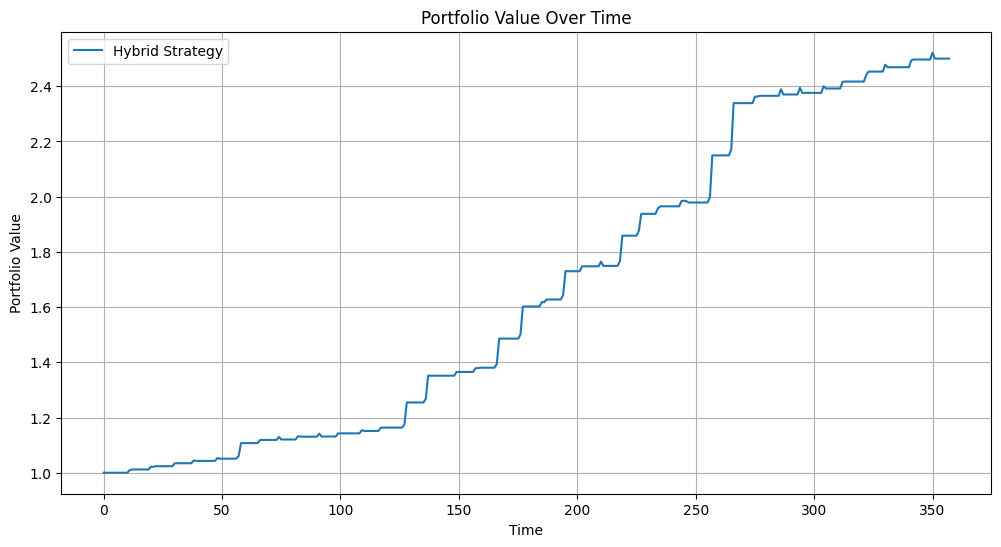

In [162]:
results = backtest_hybrid_strategy(
    backtest_df,
    stop_loss_pct=0.03,
    take_profit_pct=0.05,
    position_size=0.01,
    transaction_cost=0.01,
    slippage=0.002,
    cooldown_period=7,
    min_svm_prob=0.7
)
print(f"P&L: {results['P&L']:.4f}")
print(f"Sharpe Ratio: {results['Sharpe Ratio']:.4f}")
print(f"Max Drawdown: {results['Max Drawdown']:.4f}")
plt.figure(figsize=(12, 6))
plt.plot(results['Portfolio Values'], label='Hybrid Strategy')
plt.xlabel('Time')
plt.ylabel('Portfolio Value')
plt.title('Portfolio Value Over Time')
plt.legend()
plt.grid(True)
plt.show()